In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
try:
    df = pd.read_csv('/content/drive/MyDrive/Diploma project 2026/data.csv', sep=';')
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Error: 'data.csv' not found")

Dataset loaded successfully.



In [1]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(how='all')
df = df.dropna(subset=['Model'])
metrics = ['Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5']
for col in metrics:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=metrics)

NameError: name 'df' is not defined

In [ ]:
# Calculate overall model performance
model_performance = df.groupby('Model')[metrics].mean().sort_values(by='Accuracy_0_2', ascending=False)
# Analysis by language
lang_performance = df.groupby(['Language', 'Model'])[metrics].mean().reset_index()
# Analysis by difficulty level
level_performance = df.groupby(['Level', 'Model'])[metrics].mean().reset_index()

/tmp/ipykernel_3352/2005729957.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


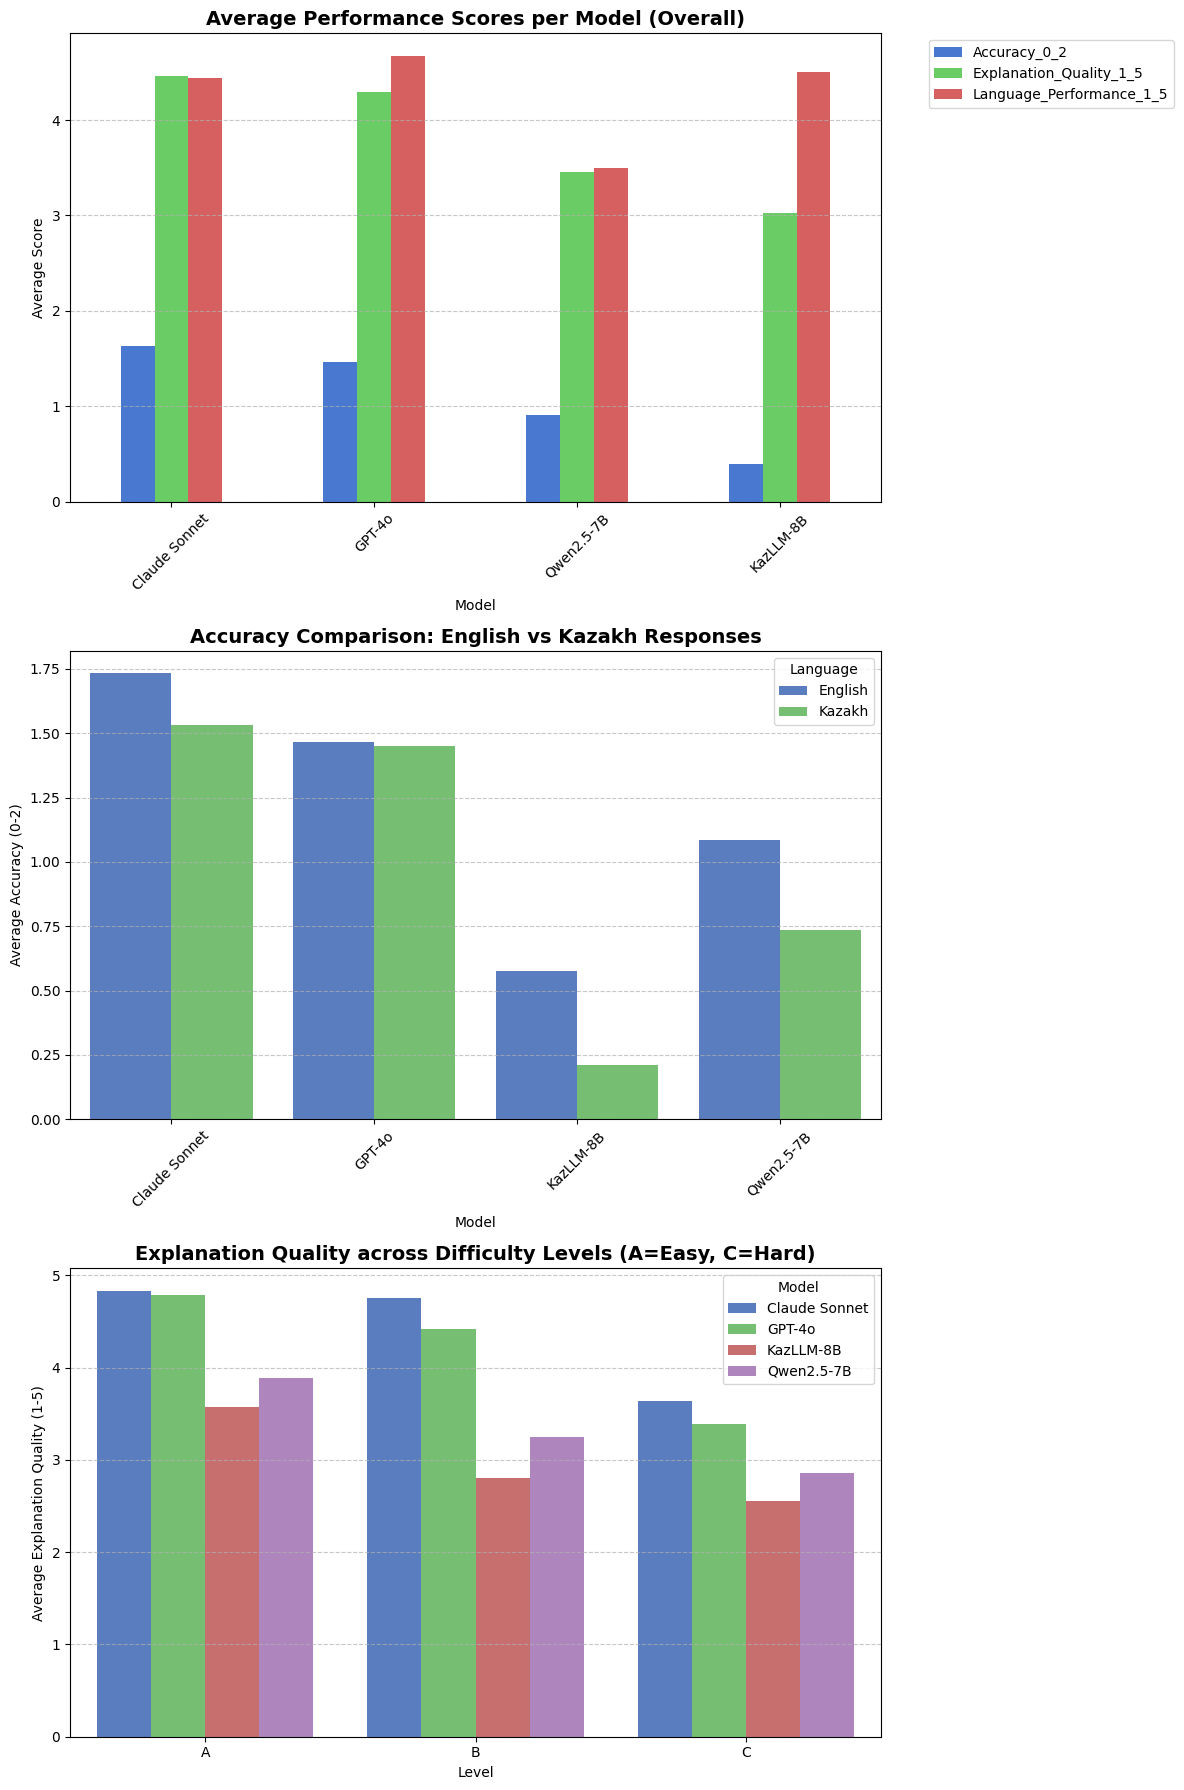

In [ ]:
#Visualizations
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
# Plot 1: Overall average scores by model
model_performance.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Average Performance Scores per Model (Overall)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Score')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Plot 2: Accuracy comparison by language
sns.barplot(data=lang_performance, x='Model', y='Accuracy_0_2', hue='Language', ax=axes[1])
axes[1].set_title('Accuracy Comparison: English vs Kazakh Responses', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Accuracy (0-2)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
# Plot 3: Explanation quality by problem level
sns.barplot(data=level_performance, x='Level', y='Explanation_Quality_1_5', hue='Model', ax=axes[2])
axes[2].set_title('Explanation Quality across Difficulty Levels (A=Easy, C=Hard)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Average Explanation Quality (1-5)')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Explanation quality by level table version
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
pivot = df.pivot_table(values='Explanation_Quality_1_5', index='Level', columns='Model', aggfunc='mean')
pivot = pivot[models_order].reindex(['A', 'B', 'C'])
pivot.index = ['A (Basic)', 'B (Intermediate)', 'C (Advanced)']
print(pivot.round(2))

Model             Claude Sonnet  GPT-4o  Qwen2.5-7B  KazLLM-8B
A (Basic)                  4.83    4.78        3.88       3.58
B (Intermediate)           4.75    4.42        3.25       2.80
C (Advanced)               3.64    3.39        2.86       2.55


In [ ]:
result = df.groupby(['Model', 'Language'])[metrics].mean().round(2)
print(result)

                        Accuracy_0_2  Explanation_Quality_1_5  \
Model         Language                                          
Claude Sonnet English           1.73                     4.60   
              Kazakh            1.53                     4.32   
GPT-4o        English           1.47                     4.32   
              Kazakh            1.45                     4.27   
KazLLM-8B     English           0.58                     3.64   
              Kazakh            0.21                     2.42   
Qwen2.5-7B    English           1.08                     3.78   
              Kazakh            0.73                     3.12   

                        Language_Performance_1_5  
Model         Language                            
Claude Sonnet English                       5.00  
              Kazakh                        3.88  
GPT-4o        English                       5.00  
              Kazakh                        4.35  
KazLLM-8B     English                      

/tmp/ipykernel_3352/4215022676.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Model', y=metric, hue='Language', ax=ax,
/tmp/ipykernel_3352/4215022676.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_3352/4215022676.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Model', y=metric, hue='Language', ax=ax,
/tmp/ipykernel_3352/4215022676.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_3352/4215022676.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.ba

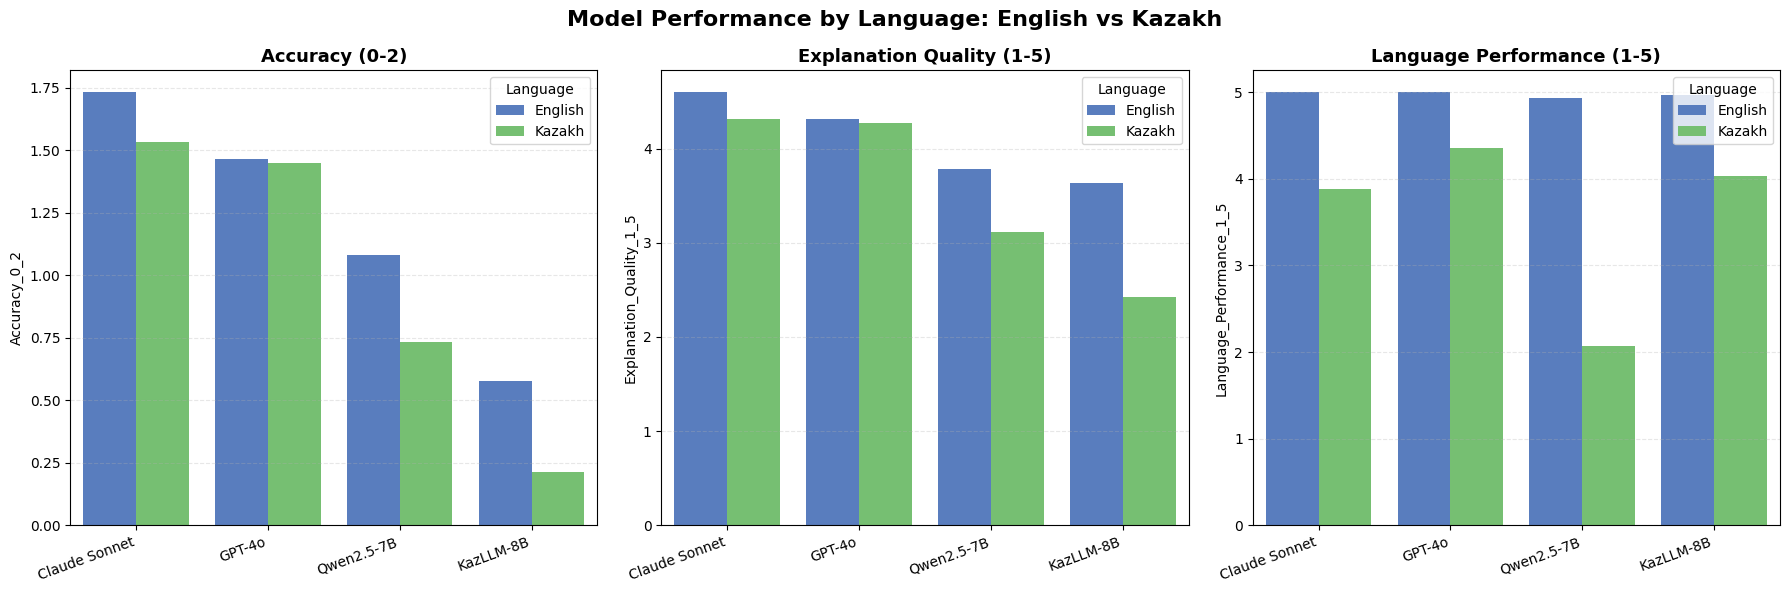

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Accuracy (0-2)', 'Explanation Quality (1-5)', 'Language Performance (1-5)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    sns.barplot(data=df, x='Model', y=metric, hue='Language', ax=ax,
                order=['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B'],
                ci=None)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_xlabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Model Performance by Language: English vs Kazakh', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/performance_by_language.png', dpi=300, bbox_inches='tight')
plt.show()

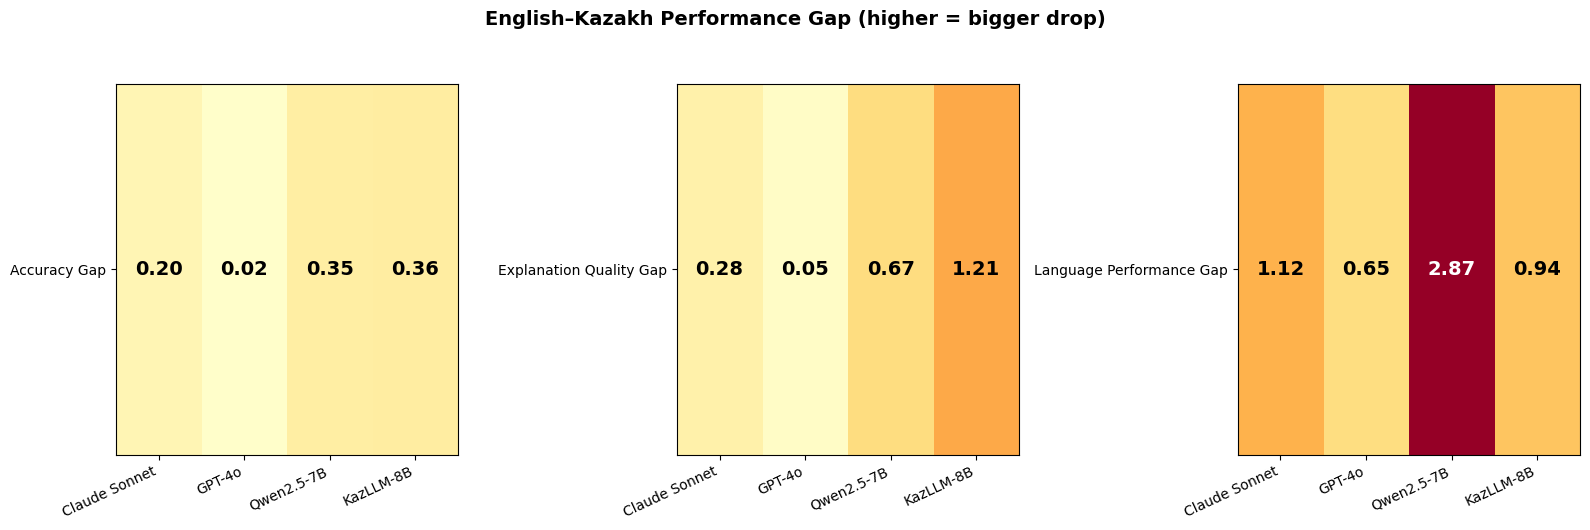

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_labels = ['Accuracy Gap', 'Explanation Quality Gap', 'Language Performance Gap']
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    pivot = df.pivot_table(values=metric, index='Model', columns='Language', aggfunc='mean')
    pivot = pivot.reindex(models_order)
    gap = pivot['English'] - pivot['Kazakh']
    gap_matrix = pd.DataFrame([gap.values], columns=models_order, index=[label])
    im = ax.imshow(gap_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=3)
    ax.set_xticks(range(len(models_order)))
    ax.set_xticklabels(models_order, rotation=25, ha='right')
    ax.set_yticks([0])
    ax.set_yticklabels([label])
    for j, val in enumerate(gap_matrix.values[0]):
        color = 'white' if val > 1.5 else 'black'
        ax.text(j, 0, f'{val:.2f}', ha='center', va='center', fontsize=14, fontweight='bold', color=color)

fig.suptitle('English–Kazakh Performance Gap (higher = bigger drop)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/language_gap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

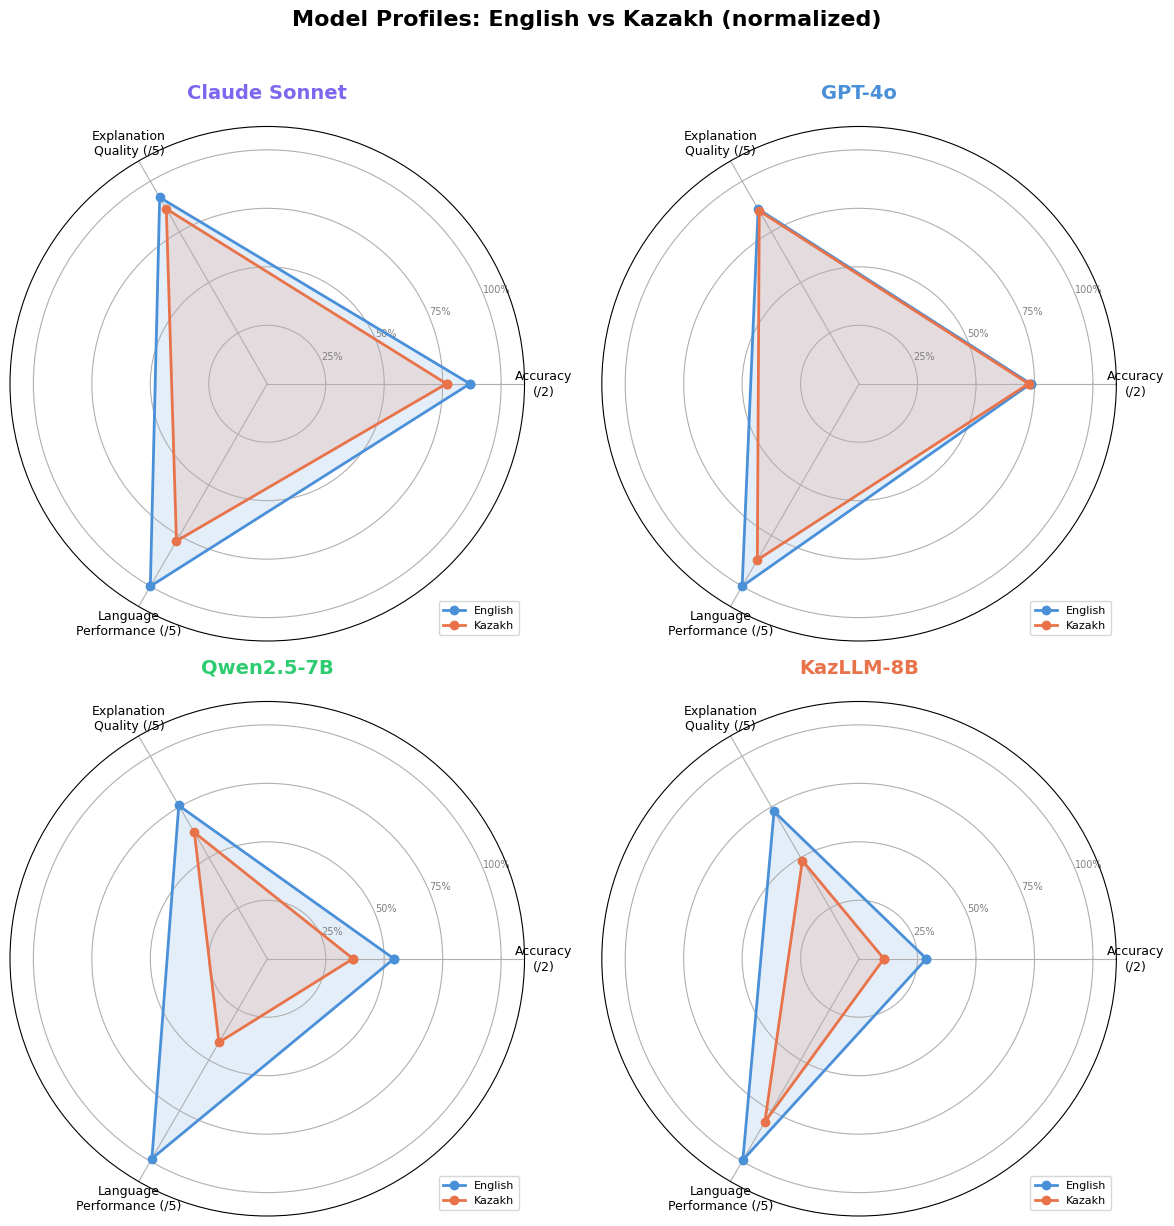

In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
colors = {'Claude Sonnet': '#7B68EE', 'GPT-4o': '#4A90D9', 'Qwen2.5-7B': '#2ECC71', 'KazLLM-8B': '#E8734A'}
categories = ['Accuracy\n(/2)', 'Explanation\nQuality (/5)', 'Language\nPerformance (/5)']
max_vals = [2, 5, 5]

for idx, model in enumerate(models_order):
    ax = axes[idx // 2][idx % 2]
    subset = df[df['Model'] == model]
    en_vals = [subset[subset['Language']=='English'][m].mean() / mx for m, mx in zip(metrics, max_vals)]
    kz_vals = [subset[subset['Language']=='Kazakh'][m].mean() / mx for m, mx in zip(metrics, max_vals)]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    en_vals += en_vals[:1]
    kz_vals += kz_vals[:1]
    angles += angles[:1]
    ax.plot(angles, en_vals, 'o-', linewidth=2, label='English', color='#4A90D9')
    ax.fill(angles, en_vals, alpha=0.15, color='#4A90D9')
    ax.plot(angles, kz_vals, 'o-', linewidth=2, label='Kazakh', color='#E8734A')
    ax.fill(angles, kz_vals, alpha=0.15, color='#E8734A')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='gray')
    ax.set_title(model, fontsize=14, fontweight='bold', pad=20, color=colors[model])
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Model Profiles: English vs Kazakh (normalized)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/radar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

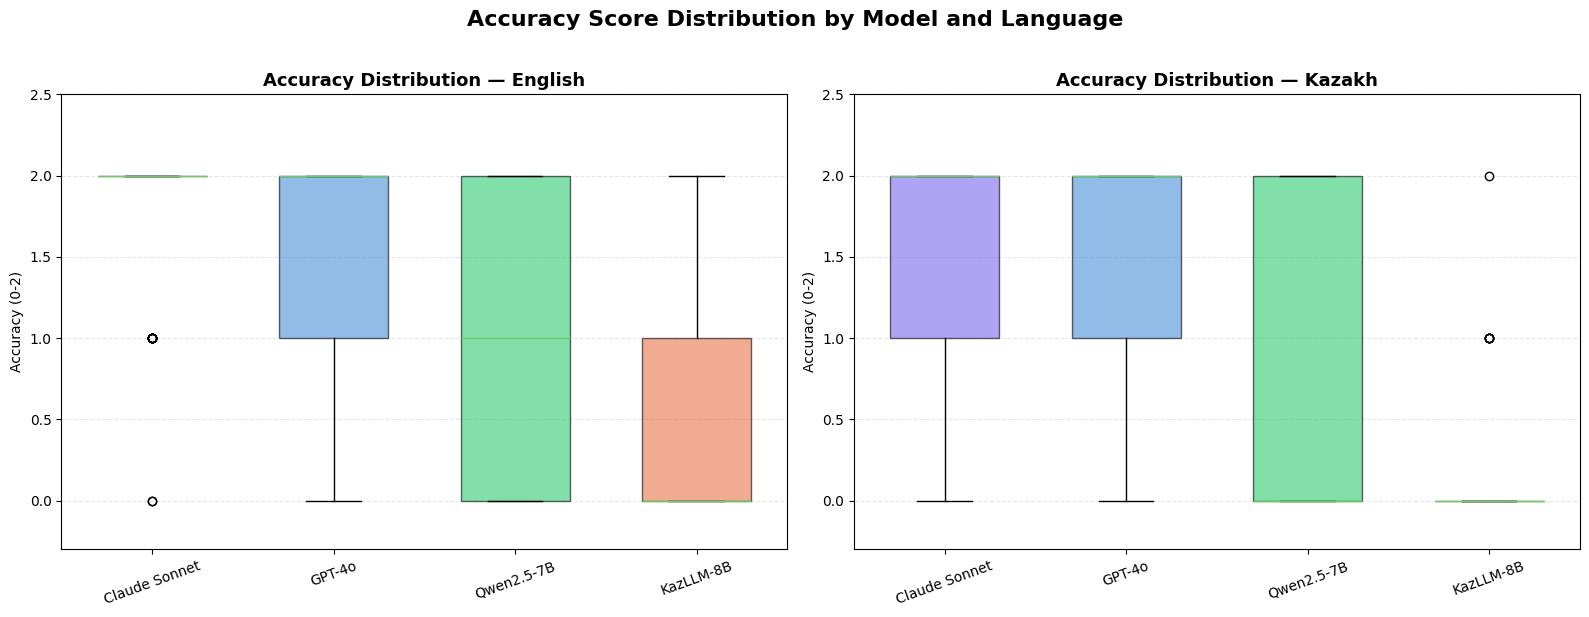

In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
box_colors = ['#7B68EE', '#4A90D9', '#2ECC71', '#E8734A']

for idx, lang in enumerate(['English', 'Kazakh']):
    ax = axes[idx]
    subset = df[df['Language'] == lang]
    box_data = [subset[subset['Model'] == m]['Accuracy_0_2'].dropna().values for m in models_order]
    bp = ax.boxplot(box_data, tick_labels=models_order, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'Accuracy Distribution — {lang}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy (0-2)')
    ax.set_ylim(-0.3, 2.5)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Accuracy Score Distribution by Model and Language', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/accuracy_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

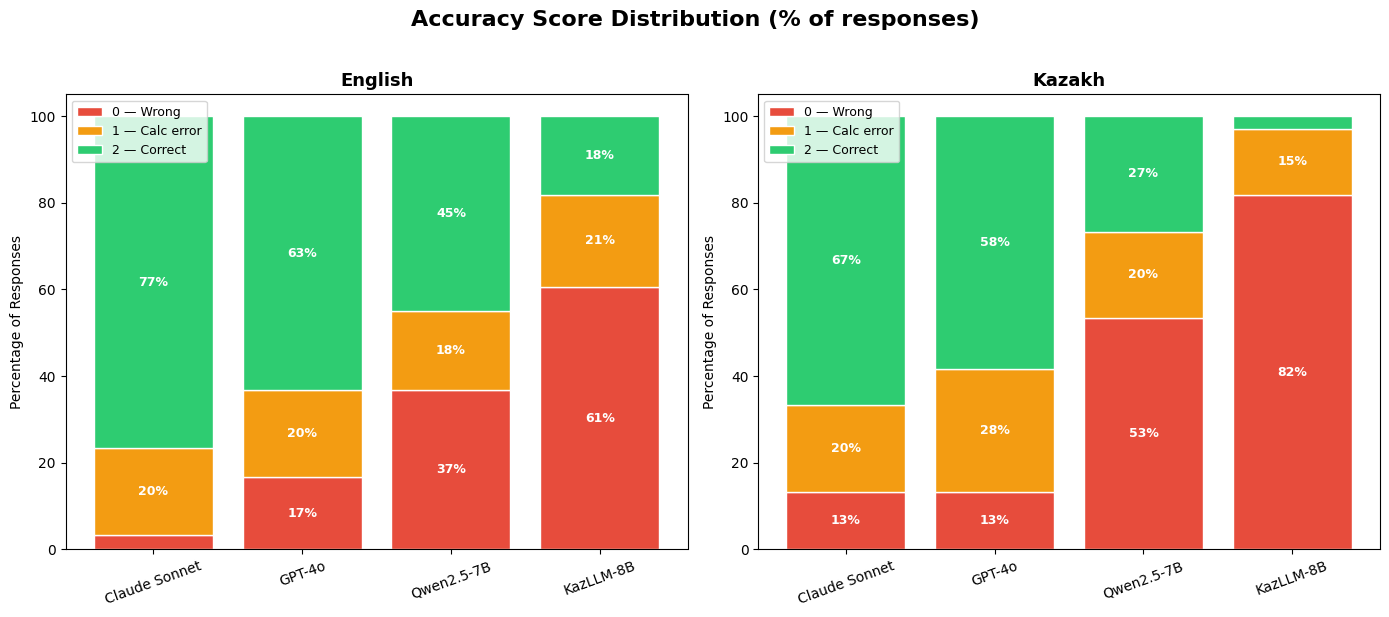

In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, lang in enumerate(['English', 'Kazakh']):
    ax = axes[idx]
    subset = df[df['Language'] == lang]
    counts = subset.groupby(['Model', 'Accuracy_0_2']).size().unstack(fill_value=0)
    counts = counts.reindex(models_order)
    for v in [0, 1, 2]:
        if v not in counts.columns:
            counts[v] = 0
    counts = counts[[0, 1, 2]]
    pcts = counts.div(counts.sum(axis=1), axis=0) * 100
    colors_acc = ['#E74C3C', '#F39C12', '#2ECC71']
    labels_acc = ['0 — Wrong', '1 — Calc error', '2 — Correct']
    bottom = np.zeros(len(models_order))
    for score, color, label in zip([0, 1, 2], colors_acc, labels_acc):
        vals = pcts[score].values
        bars = ax.bar(models_order, vals, bottom=bottom, color=color, label=label, edgecolor='white')
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        bottom += vals
    ax.set_title(f'{lang}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage of Responses')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Accuracy Score Distribution (% of responses)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/accuracy_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

# TABLE 1: Overall
for lang in ['English', 'Kazakh']:
    print(f"\n--- {lang} ---")
    subset = df[df['Language'] == lang]
    counts = subset.groupby(['Model', 'Accuracy_0_2']).size().unstack(fill_value=0).reindex(models_order)
    for v in [0, 1, 2]:
        if v not in counts.columns:
            counts[v] = 0
    counts = counts[[0, 1, 2]]
    total = counts.sum(axis=1)
    pcts = counts.div(total, axis=0) * 100
    result = pd.DataFrame({
        '0-Wrong': [f"{int(counts.loc[m,0])} ({pcts.loc[m,0]:.1f}%)" for m in models_order],
        '1-Calc Error': [f"{int(counts.loc[m,1])} ({pcts.loc[m,1]:.1f}%)" for m in models_order],
        '2-Correct': [f"{int(counts.loc[m,2])} ({pcts.loc[m,2]:.1f}%)" for m in models_order],
        'Total': [int(total.loc[m]) for m in models_order],
    }, index=models_order)
    print(result)

# TABLE 2: By Level
for level in ['A', 'B', 'C']:
    print(f"\n{'='*50}\nLevel {level}\n{'='*50}")
    for lang in ['English', 'Kazakh']:
        print(f"\n  {lang}:")
        subset = df[(df['Language'] == lang) & (df['Level'] == level)]
        counts = subset.groupby(['Model', 'Accuracy_0_2']).size().unstack(fill_value=0).reindex(models_order)
        for v in [0, 1, 2]:
            if v not in counts.columns:
                counts[v] = 0
        counts = counts[[0, 1, 2]]
        total = counts.sum(axis=1)
        pcts = counts.div(total, axis=0) * 100
        result = pd.DataFrame({
            '0-Wrong': [f"{int(counts.loc[m,0])} ({pcts.loc[m,0]:.1f}%)" for m in models_order],
            '1-Calc Error': [f"{int(counts.loc[m,1])} ({pcts.loc[m,1]:.1f}%)" for m in models_order],
            '2-Correct': [f"{int(counts.loc[m,2])} ({pcts.loc[m,2]:.1f}%)" for m in models_order],
            'Total': [int(total.loc[m]) for m in models_order],
        }, index=models_order)
        print(result)


--- English ---
                  0-Wrong 1-Calc Error   2-Correct  Total
Claude Sonnet    2 (3.3%)   12 (20.0%)  46 (76.7%)     60
GPT-4o         10 (16.7%)   12 (20.0%)  38 (63.3%)     60
Qwen2.5-7B     22 (36.7%)   11 (18.3%)  27 (45.0%)     60
KazLLM-8B      20 (60.6%)    7 (21.2%)   6 (18.2%)     33

--- Kazakh ---
                  0-Wrong 1-Calc Error   2-Correct  Total
Claude Sonnet   8 (13.3%)   12 (20.0%)  40 (66.7%)     60
GPT-4o          8 (13.3%)   17 (28.3%)  35 (58.3%)     60
Qwen2.5-7B     32 (53.3%)   12 (20.0%)  16 (26.7%)     60
KazLLM-8B      27 (81.8%)    5 (15.2%)    1 (3.0%)     33

Level A

  English:
                 0-Wrong 1-Calc Error   2-Correct  Total
Claude Sonnet   0 (0.0%)     1 (3.3%)  29 (96.7%)     30
GPT-4o          2 (6.7%)     2 (6.7%)  26 (86.7%)     30
Qwen2.5-7B      2 (6.7%)    5 (16.7%)  23 (76.7%)     30
KazLLM-8B      3 (23.1%)    5 (38.5%)   5 (38.5%)     13

  Kazakh:
                 0-Wrong 1-Calc Error   2-Correct  Total
Claude Sonnet

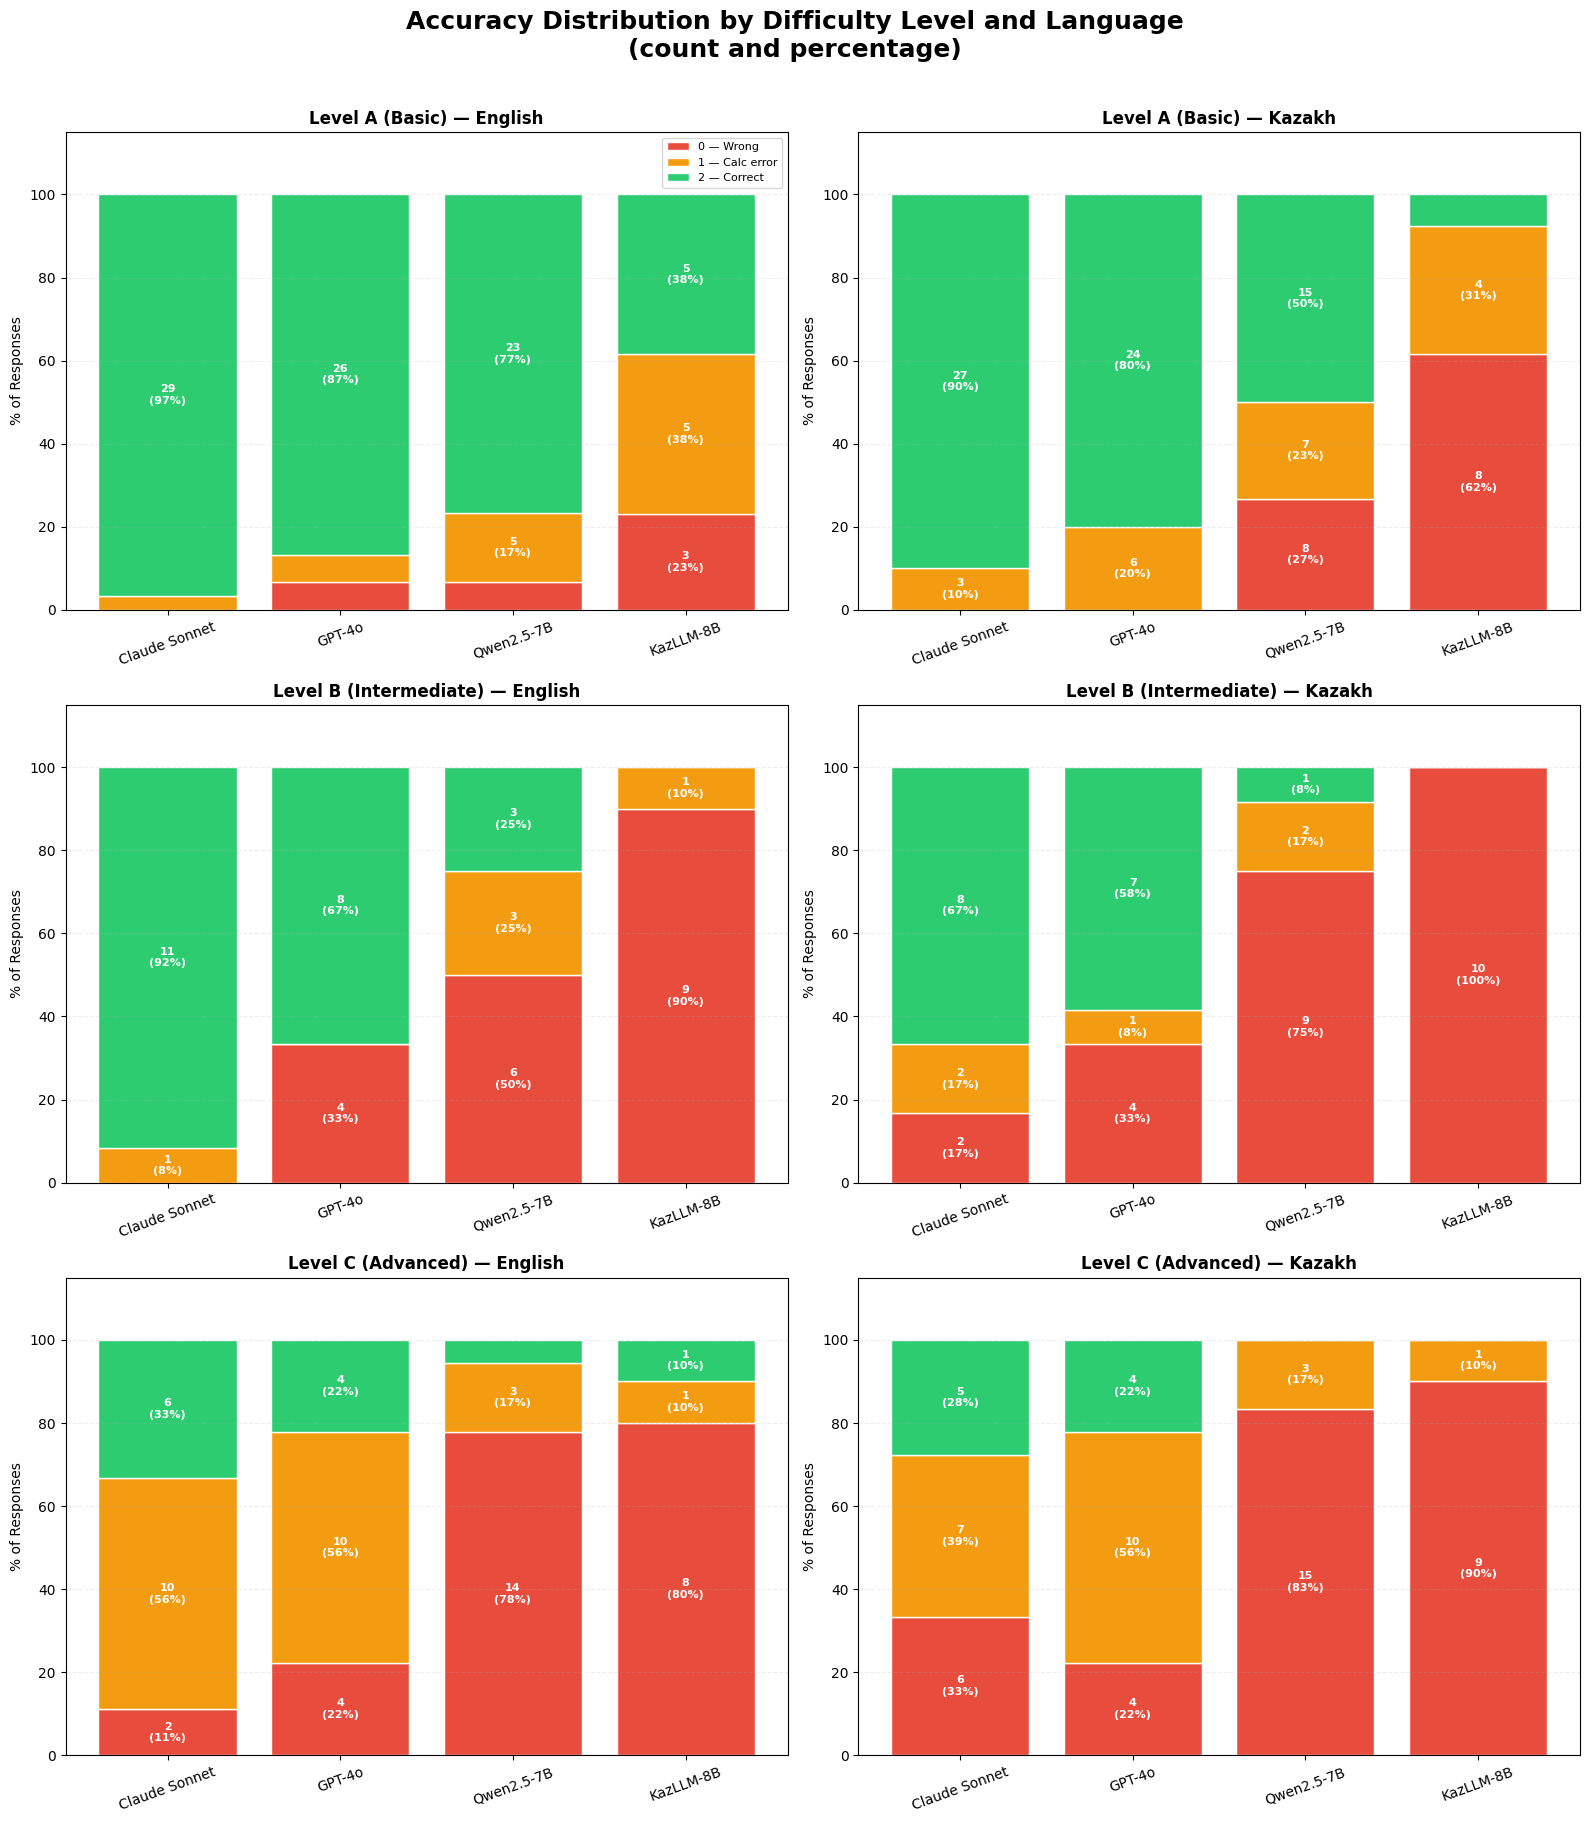

In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
colors_acc = ['#E74C3C', '#F39C12', '#2ECC71']
labels_acc = ['0 — Wrong', '1 — Calc error', '2 — Correct']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
level_labels = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}

for row_idx, level in enumerate(['A', 'B', 'C']):
    for col_idx, lang in enumerate(['English', 'Kazakh']):
        ax = axes[row_idx][col_idx]
        subset = df[(df['Language'] == lang) & (df['Level'] == level)]
        counts = subset.groupby(['Model', 'Accuracy_0_2']).size().unstack(fill_value=0)
        counts = counts.reindex(models_order)
        for v in [0, 1, 2]:
            if v not in counts.columns:
                counts[v] = 0
        counts = counts[[0, 1, 2]]
        total = counts.sum(axis=1)
        pcts = counts.div(total, axis=0) * 100
        bottom = np.zeros(len(models_order))
        for score, color, label in zip([0, 1, 2], colors_acc, labels_acc):
            vals = pcts[score].values
            raw = counts[score].values
            bars = ax.bar(models_order, vals, bottom=bottom, color=color, label=label, edgecolor='white')
            for j, (bar, val, r) in enumerate(zip(bars, vals, raw)):
                if val > 8:
                    ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                           f'{int(r)}\n({val:.0f}%)', ha='center', va='center',
                           fontsize=8, fontweight='bold', color='white')
            bottom += vals
        ax.set_title(f'{level_labels[level]} — {lang}', fontsize=12, fontweight='bold')
        ax.set_ylabel('% of Responses')
        ax.set_ylim(0, 115)
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', linestyle='--', alpha=0.2)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

fig.suptitle('Accuracy Distribution by Difficulty Level and Language\n(count and percentage)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/accuracy_stacked_by_level_counts.png', dpi=300, bbox_inches='tight')
plt.show()

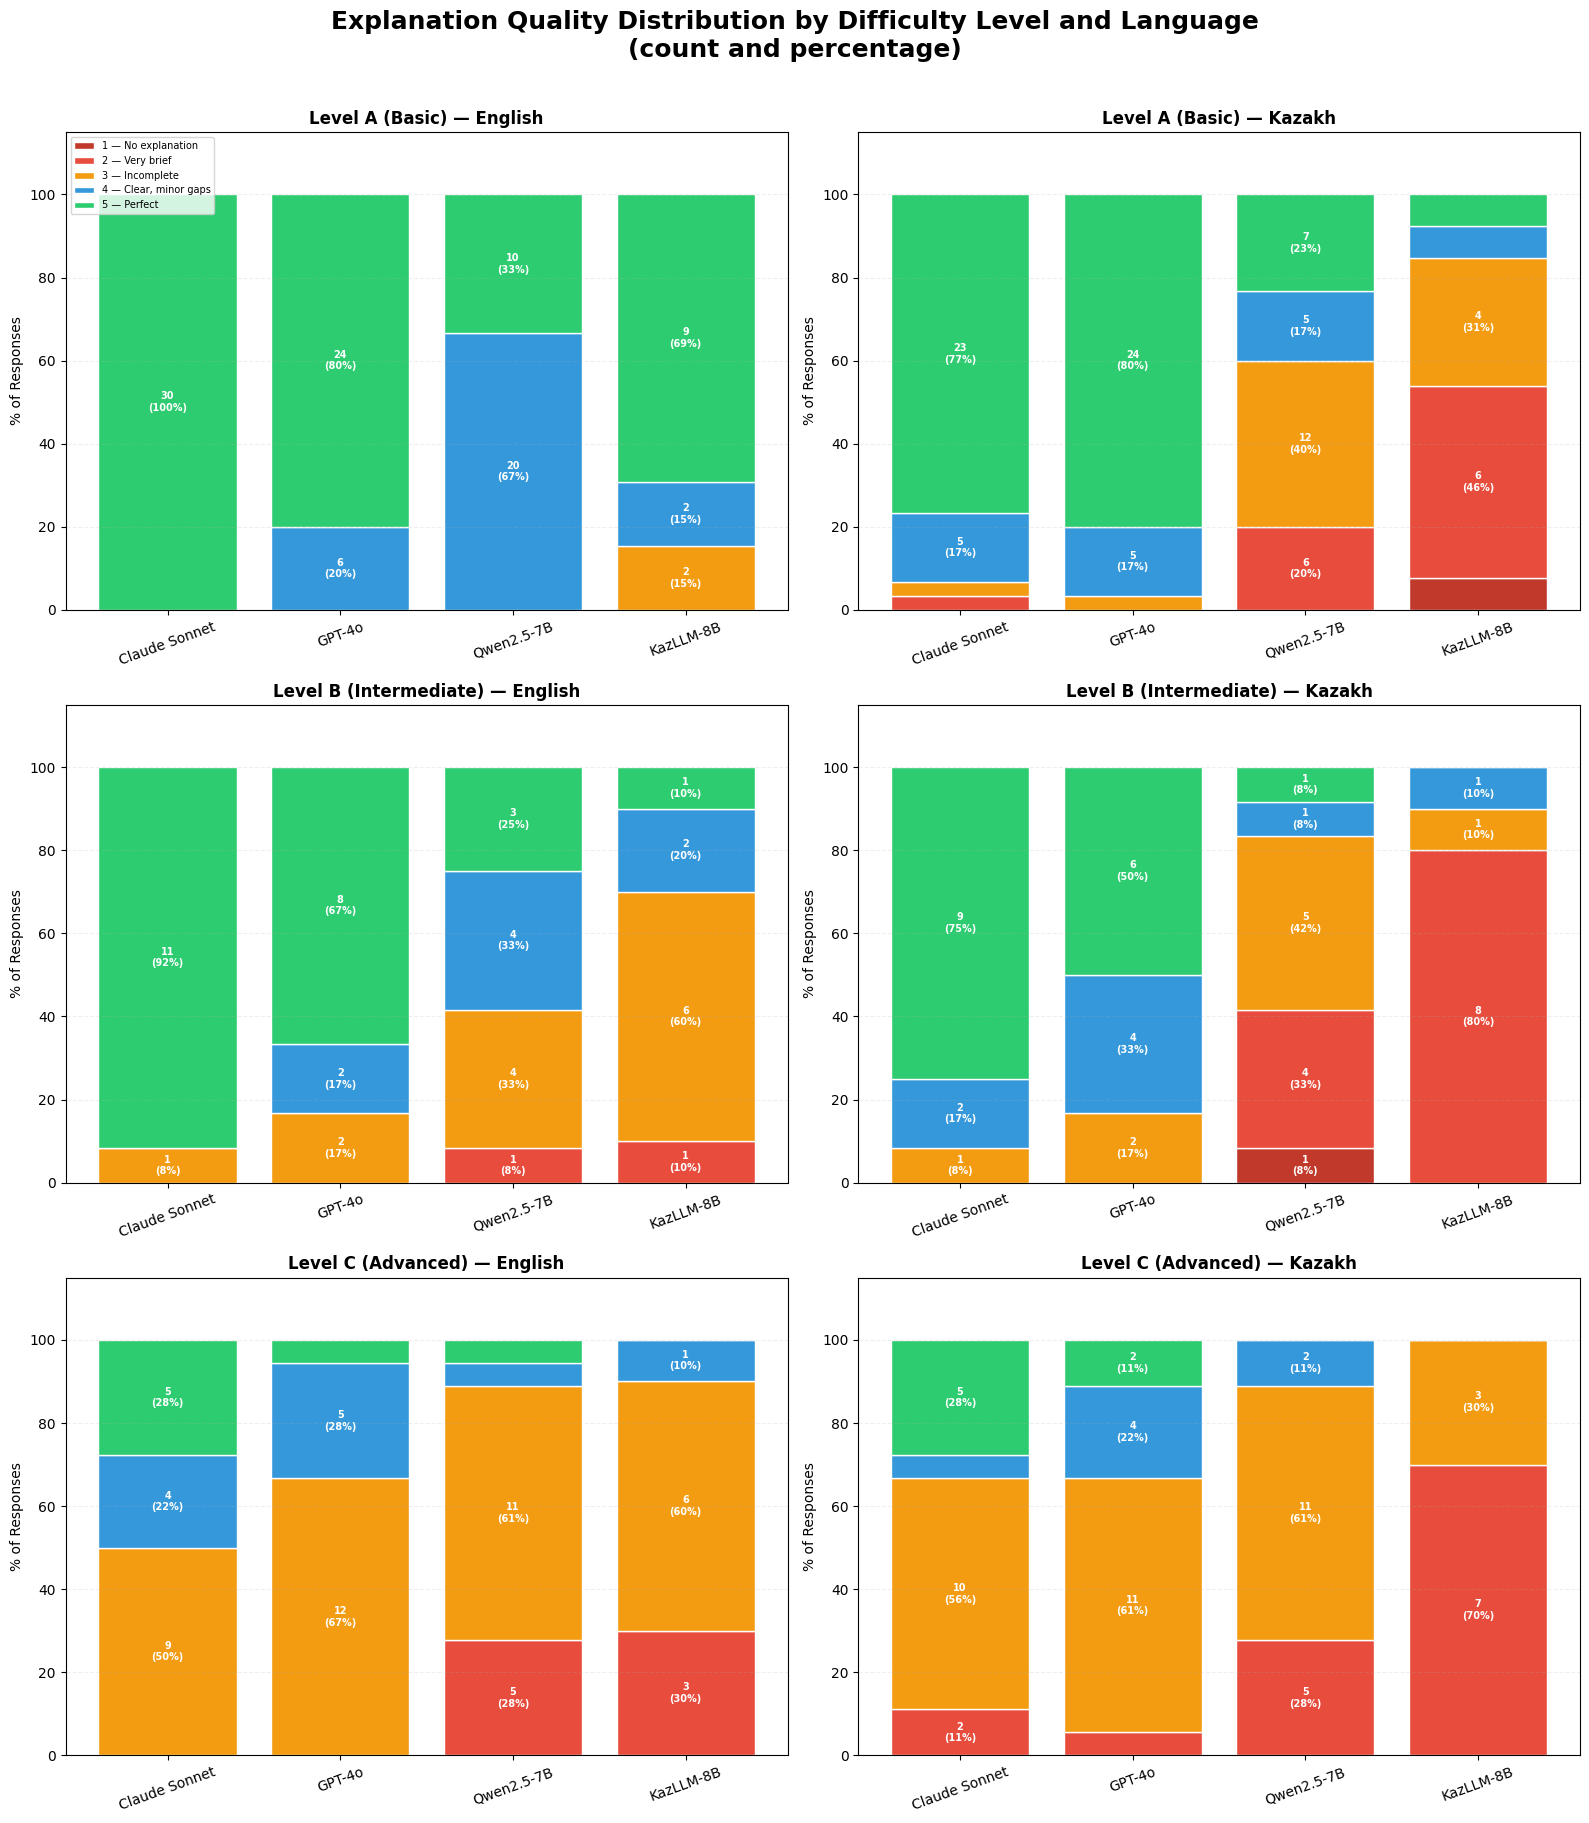

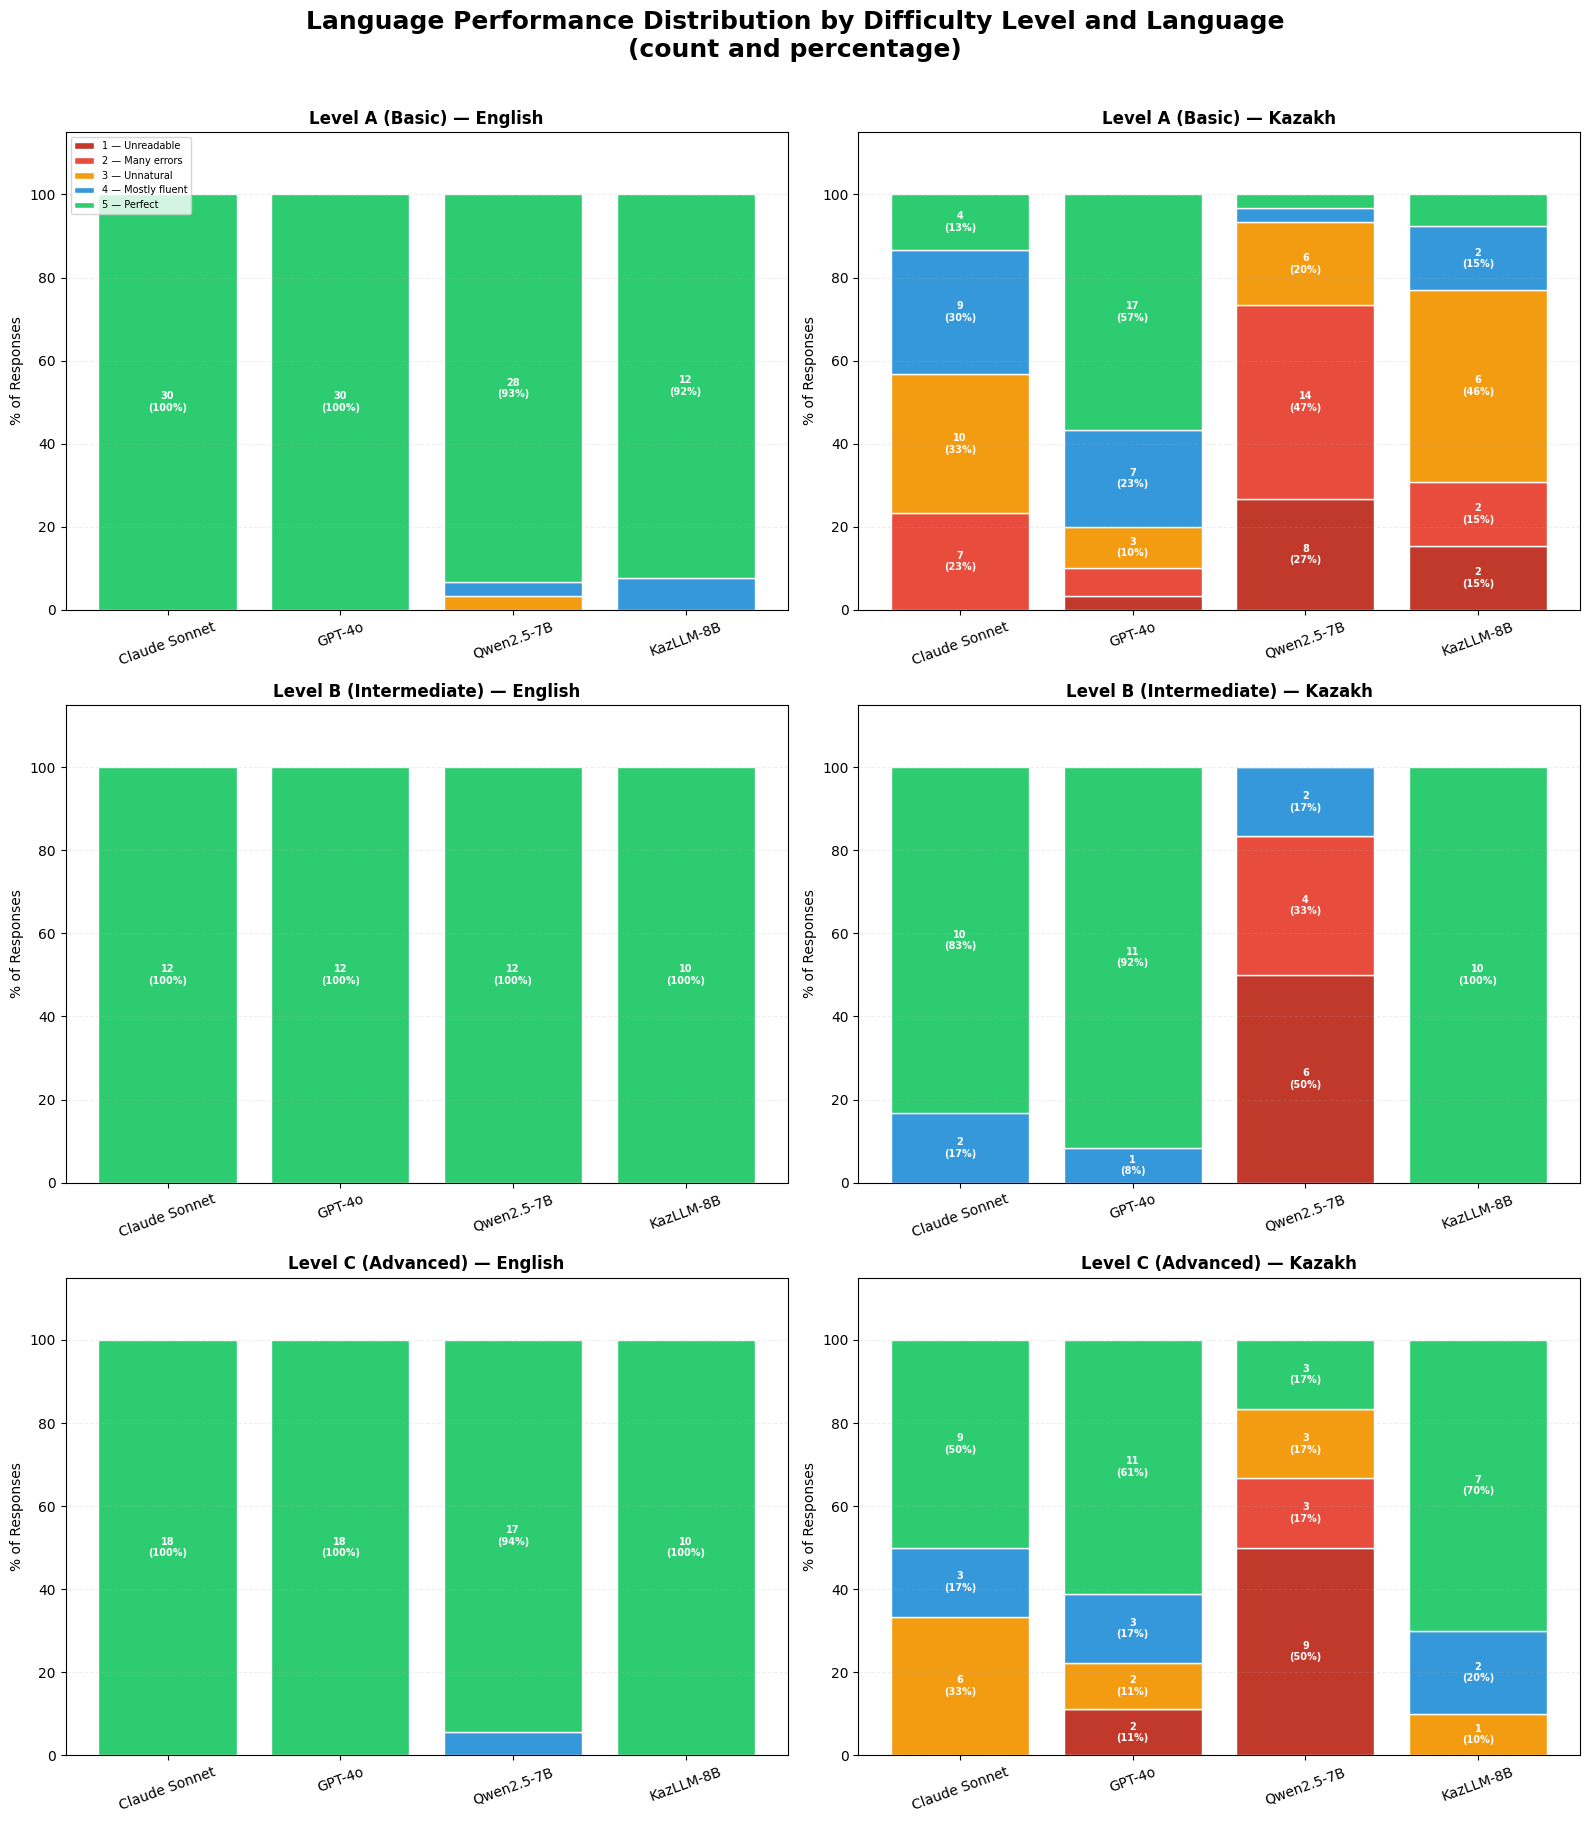

In [ ]:
def make_stacked_chart(df, metric, scores, score_labels, colors, title, filename):
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    level_labels = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}
    models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
    for row_idx, level in enumerate(['A', 'B', 'C']):
        for col_idx, lang in enumerate(['English', 'Kazakh']):
            ax = axes[row_idx][col_idx]
            subset = df[(df['Language'] == lang) & (df['Level'] == level)]
            counts = subset.groupby(['Model', metric]).size().unstack(fill_value=0).reindex(models_order)
            for v in scores:
                if v not in counts.columns:
                    counts[v] = 0
            counts = counts[scores]
            total = counts.sum(axis=1)
            pcts = counts.div(total, axis=0) * 100
            bottom = np.zeros(len(models_order))
            for score, color, label in zip(scores, colors, score_labels):
                vals = pcts[score].values
                raw = counts[score].values
                bars = ax.bar(models_order, vals, bottom=bottom, color=color, label=label, edgecolor='white')
                for j, (bar, val, r) in enumerate(zip(bars, vals, raw)):
                    if val > 8:
                        ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                               f'{int(r)}\n({val:.0f}%)', ha='center', va='center',
                               fontsize=7, fontweight='bold', color='white')
                bottom += vals
            ax.set_title(f'{level_labels[level]} — {lang}', fontsize=12, fontweight='bold')
            ax.set_ylabel('% of Responses')
            ax.set_ylim(0, 115)
            ax.tick_params(axis='x', rotation=20)
            ax.grid(axis='y', linestyle='--', alpha=0.2)
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7, loc='upper left')
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/Diploma project 2026/{filename}', dpi=300, bbox_inches='tight')
    plt.show()

# Explanation Quality
make_stacked_chart(df, 'Explanation_Quality_1_5',
    [1, 2, 3, 4, 5],
    ['1 — No explanation', '2 — Very brief', '3 — Incomplete', '4 — Clear, minor gaps', '5 — Perfect'],
    ['#C0392B', '#E74C3C', '#F39C12', '#3498DB', '#2ECC71'],
    'Explanation Quality Distribution by Difficulty Level and Language\n(count and percentage)',
    'explanation_stacked_by_level.png')

# Language Performance
make_stacked_chart(df, 'Language_Performance_1_5',
    [1, 2, 3, 4, 5],
    ['1 — Unreadable', '2 — Many errors', '3 — Unnatural', '4 — Mostly fluent', '5 — Perfect'],
    ['#C0392B', '#E74C3C', '#F39C12', '#3498DB', '#2ECC71'],
    'Language Performance Distribution by Difficulty Level and Language\n(count and percentage)',
    'language_perf_stacked_by_level.png')

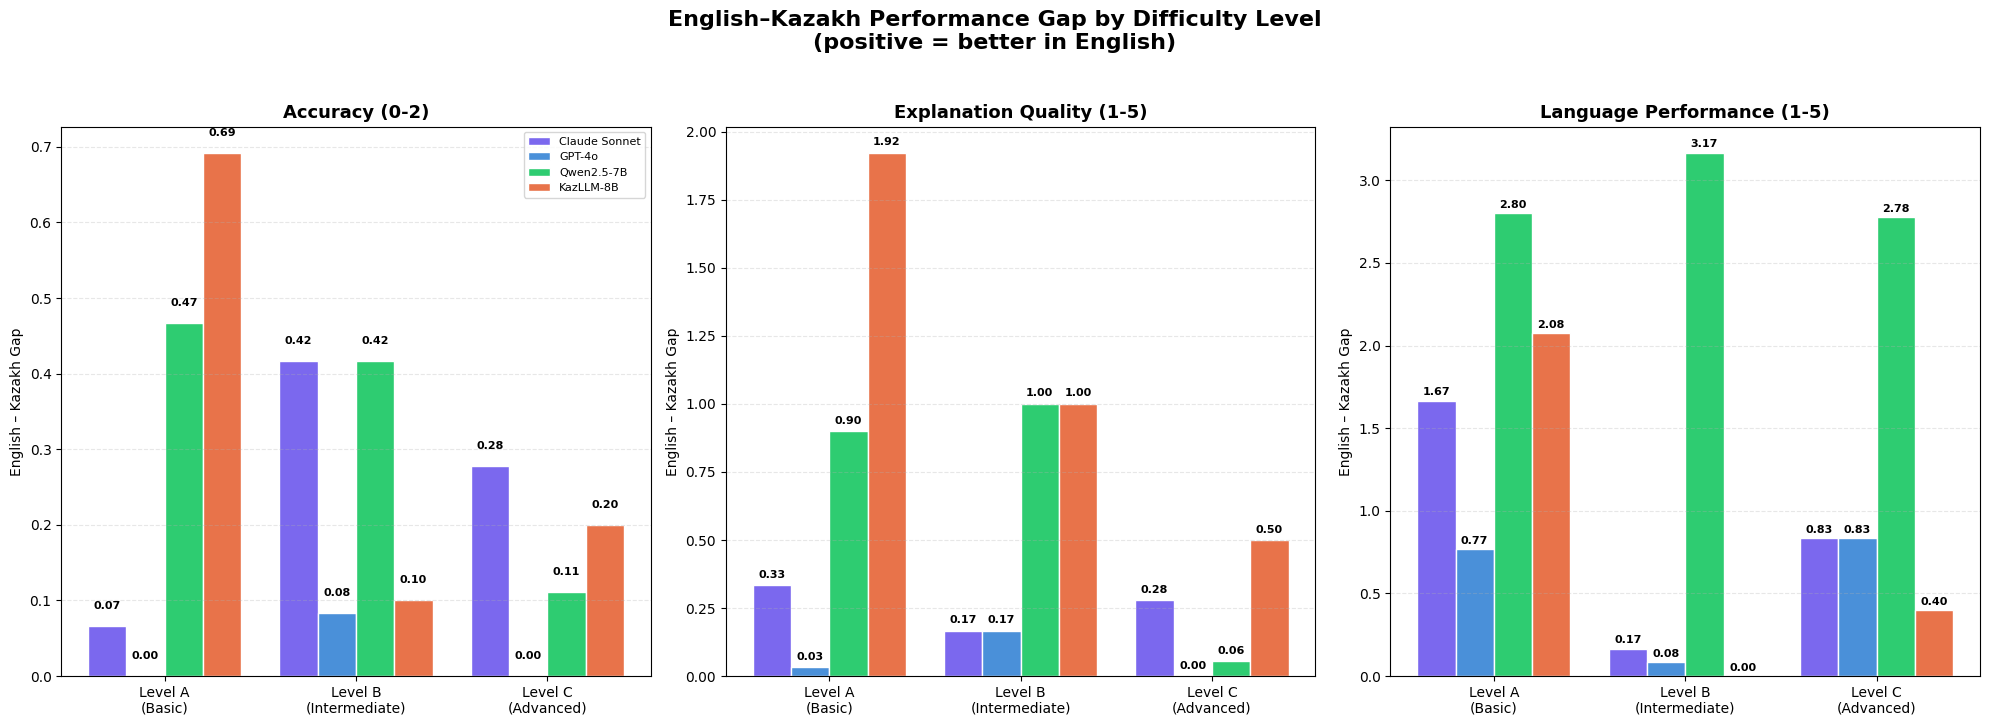

In [ ]:
colors_model = {'Claude Sonnet': '#7B68EE', 'GPT-4o': '#4A90D9', 'Qwen2.5-7B': '#2ECC71', 'KazLLM-8B': '#E8734A'}
levels = ['A', 'B', 'C']
metrics = ['Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5']
metric_names = ['Accuracy (0-2)', 'Explanation Quality (1-5)', 'Language Performance (1-5)']
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
x = np.arange(len(levels))
width = 0.2

for idx, (metric, mname) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx]
    for i, model in enumerate(models_order):
        gaps = []
        for level in levels:
            subset = df[df['Level'] == level]
            pivot = subset.pivot_table(values=metric, index='Model', columns='Language', aggfunc='mean')
            if model in pivot.index:
                gaps.append(pivot.loc[model, 'English'] - pivot.loc[model, 'Kazakh'])
            else:
                gaps.append(0)
        bars = ax.bar(x + i * width, gaps, width, label=model, color=colors_model[model], edgecolor='white')
        for bar, val in zip(bars, gaps):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['Level A\n(Basic)', 'Level B\n(Intermediate)', 'Level C\n(Advanced)'])
    ax.set_ylabel('English – Kazakh Gap')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('English–Kazakh Performance Gap by Difficulty Level\n(positive = better in English)',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/gap_by_level_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

def print_distribution(df, metric, score_labels, title):
    scores = list(score_labels.keys())
    print(f"\n{'='*110}")
    print(f"{title} — Score Distribution by Model × Language")
    print(f"{'='*110}")
    for lang in ['English', 'Kazakh']:
        print(f"\n--- {lang} ---")
        subset = df[df['Language'] == lang]
        counts = subset.groupby(['Model', metric]).size().unstack(fill_value=0).reindex(models_order)
        for v in scores:
            if v not in counts.columns:
                counts[v] = 0
        counts = counts[scores]
        total = counts.sum(axis=1)
        pcts = counts.div(total, axis=0) * 100
        result = pd.DataFrame(
            {score_labels[s]: [f"{int(counts.loc[m,s])} ({pcts.loc[m,s]:.1f}%)" for m in models_order] for s in scores},
            index=models_order)
        result['Total'] = [int(total.loc[m]) for m in models_order]
        print(result)

    print(f"\n{'='*110}")
    print(f"{title} — Score Distribution by Model × Language × Level")
    print(f"{'='*110}")
    for level in ['A', 'B', 'C']:
        lname = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}
        print(f"\n{'='*70}\n  {lname[level]}\n{'='*70}")
        for lang in ['English', 'Kazakh']:
            print(f"\n  {lang}:")
            subset = df[(df['Language'] == lang) & (df['Level'] == level)]
            counts = subset.groupby(['Model', metric]).size().unstack(fill_value=0).reindex(models_order)
            for v in scores:
                if v not in counts.columns:
                    counts[v] = 0
            counts = counts[scores]
            total = counts.sum(axis=1)
            pcts = counts.div(total, axis=0) * 100
            result = pd.DataFrame(
                {score_labels[s]: [f"{int(counts.loc[m,s])} ({pcts.loc[m,s]:.1f}%)" for m in models_order] for s in scores},
                index=models_order)
            result['n'] = [int(total.loc[m]) for m in models_order]
            print(result)

# Explanation Quality
print_distribution(df, 'Explanation_Quality_1_5',
    {1:'1-No expl', 2:'2-Brief', 3:'3-Incomplete', 4:'4-Clear', 5:'5-Perfect'},
    'EXPLANATION QUALITY')

# Language Performance
print_distribution(df, 'Language_Performance_1_5',
    {1:'1-Unreadable', 2:'2-Many err', 3:'3-Unnatural', 4:'4-Mostly fl', 5:'5-Perfect'},
    'LANGUAGE PERFORMANCE')


EXPLANATION QUALITY — Score Distribution by Model × Language

--- English ---
              1-No expl    2-Brief 3-Incomplete     4-Clear   5-Perfect  Total
Claude Sonnet  0 (0.0%)   0 (0.0%)   10 (16.7%)    4 (6.7%)  46 (76.7%)     60
GPT-4o         0 (0.0%)   0 (0.0%)   14 (23.3%)  13 (21.7%)  33 (55.0%)     60
Qwen2.5-7B     0 (0.0%)  6 (10.0%)   15 (25.0%)  25 (41.7%)  14 (23.3%)     60
KazLLM-8B      0 (0.0%)  4 (12.1%)   14 (42.4%)   5 (15.2%)  10 (30.3%)     33

--- Kazakh ---
              1-No expl     2-Brief 3-Incomplete     4-Clear   5-Perfect  \
Claude Sonnet  0 (0.0%)    3 (5.0%)   12 (20.0%)   8 (13.3%)  37 (61.7%)   
GPT-4o         0 (0.0%)    1 (1.7%)   14 (23.3%)  13 (21.7%)  32 (53.3%)   
Qwen2.5-7B     1 (1.7%)  15 (25.0%)   28 (46.7%)   8 (13.3%)   8 (13.3%)   
KazLLM-8B      1 (3.0%)  21 (63.6%)    8 (24.2%)    2 (6.1%)    1 (3.0%)   

               Total  
Claude Sonnet     60  
GPT-4o            60  
Qwen2.5-7B        60  
KazLLM-8B         33  

EXPLANATION Q


Accuracy:
  Difficulty Level     48.8%
  Model                46.6%
  Language             4.7%

Explanation Quality:
  Difficulty Level     45.6%
  Model                44.5%
  Language             9.8%

Language Performance:
  Language             59.0%
  Model                26.8%
  Difficulty Level     14.3%


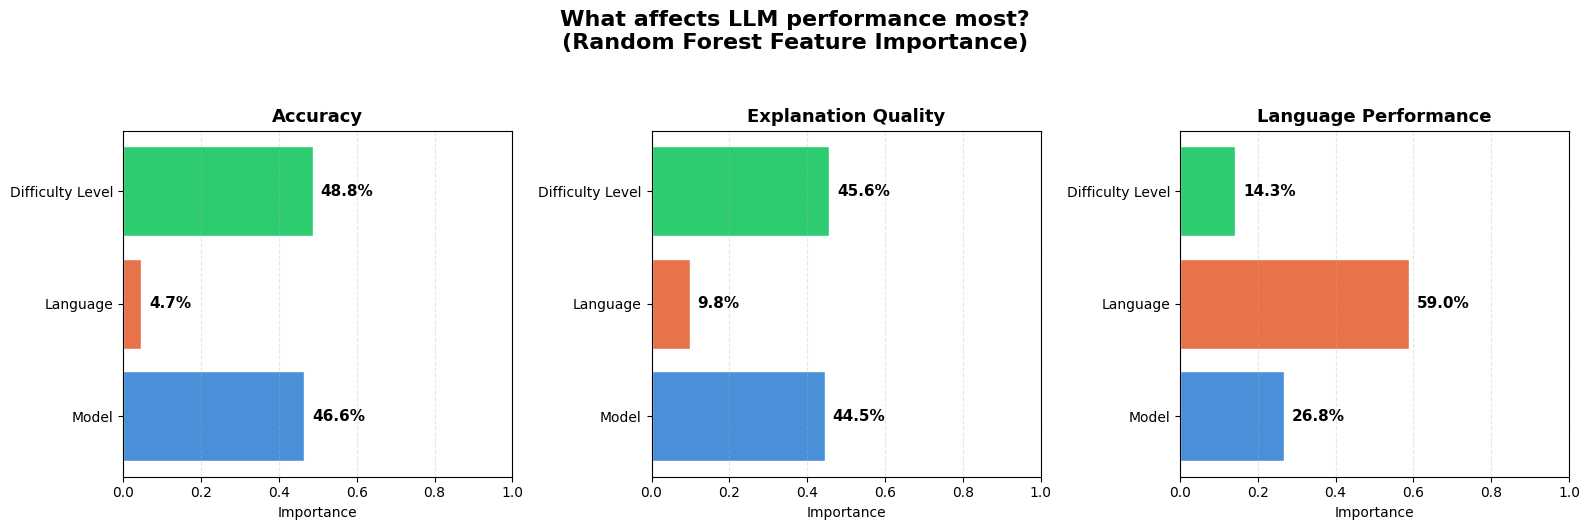

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode features
le_model = LabelEncoder()
le_lang = LabelEncoder()
le_level = LabelEncoder()

df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Language_enc'] = le_lang.fit_transform(df['Language'])
df['Level_enc'] = le_level.fit_transform(df['Level'])

features = ['Model_enc', 'Language_enc', 'Level_enc']
feature_names = ['Model', 'Language', 'Difficulty Level']
metrics = ['Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5']
metric_names = ['Accuracy', 'Explanation Quality', 'Language Performance']

# Feature importance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4A90D9', '#E8734A', '#2ECC71']

for idx, (metric, mname) in enumerate(zip(metrics, metric_names)):
    X = df[features].values
    y = df[metric].astype(int).values
    rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=5)
    rf.fit(X, y)
    importances = rf.feature_importances_

    print(f"\n{mname}:")
    for fname, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
        print(f"  {fname:20s} {imp:.1%}")

    ax = axes[idx]
    bars = ax.barh(feature_names, importances, color=colors, edgecolor='white')
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Importance')
    for bar, val in zip(bars, importances):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
               f'{val:.1%}', va='center', fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

fig.suptitle('What affects LLM performance most?\n(Random Forest Feature Importance)',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Level A (Basic) — Accuracy: Model 84.1% / Language 15.9%
Level A (Basic) — Explanation Quality: Model 77.1% / Language 22.9%
Level A (Basic) — Language Performance: Model 21.6% / Language 78.4%
Level B (Intermediate) — Accuracy: Model 91.9% / Language 8.1%
Level B (Intermediate) — Explanation Quality: Model 81.0% / Language 19.0%
Level B (Intermediate) — Language Performance: Model 58.3% / Language 41.7%
Level C (Advanced) — Accuracy: Model 93.0% / Language 7.0%
Level C (Advanced) — Explanation Quality: Model 83.4% / Language 16.6%
Level C (Advanced) — Language Performance: Model 33.7% / Language 66.3%


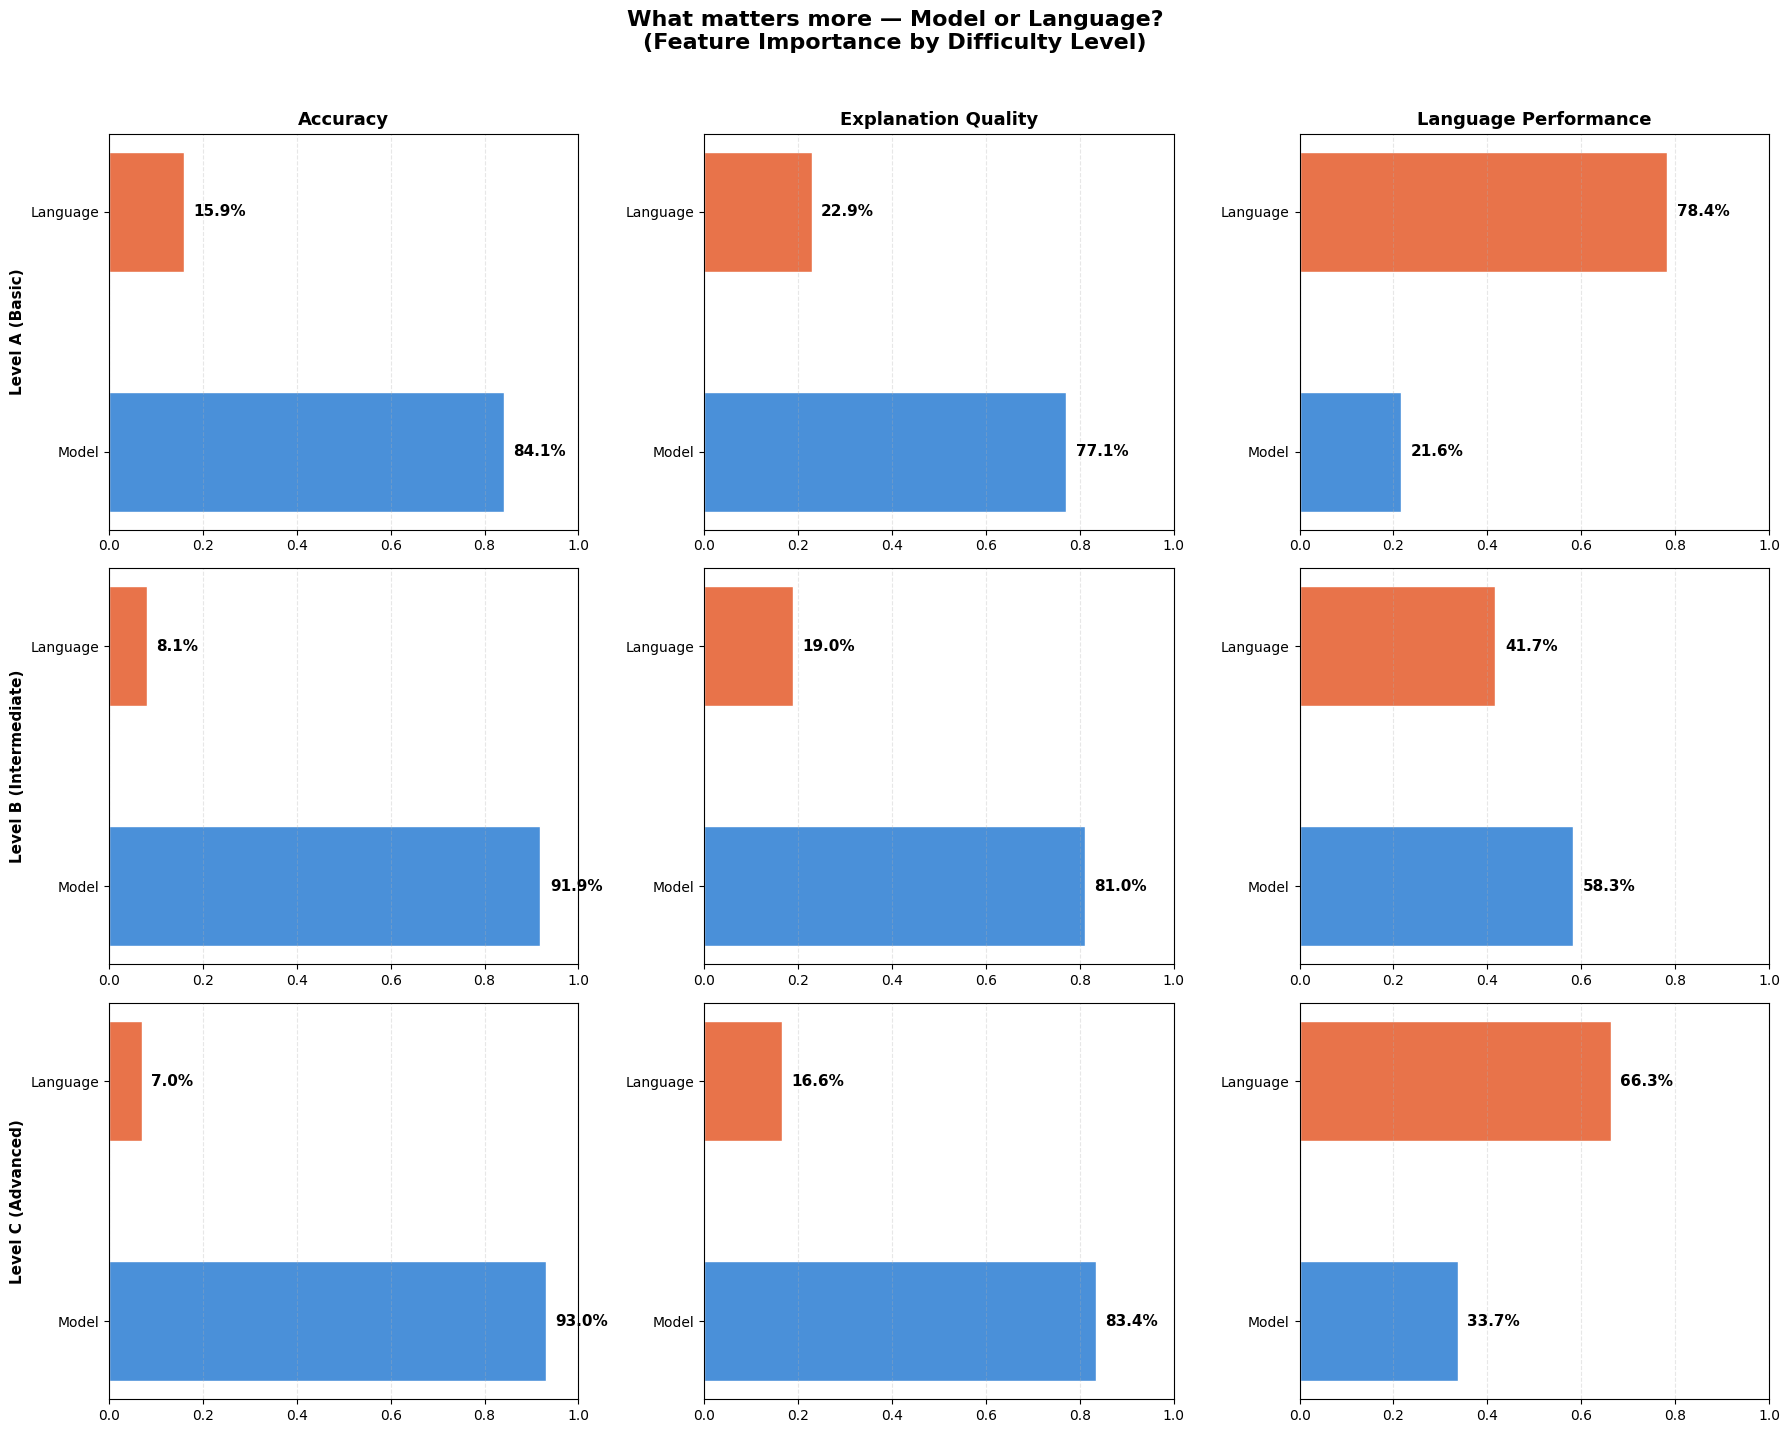

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
le_lang = LabelEncoder()
df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Language_enc'] = le_lang.fit_transform(df['Language'])

features = ['Model_enc', 'Language_enc']
feature_names = ['Model', 'Language']
metrics = ['Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5']
metric_names = ['Accuracy', 'Explanation Quality', 'Language Performance']
levels = ['A', 'B', 'C']
level_names = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, level in enumerate(levels):
    subset = df[df['Level'] == level]
    for col, (metric, mname) in enumerate(zip(metrics, metric_names)):
        X = subset[features].values
        y = subset[metric].astype(int).values
        rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=3)
        rf.fit(X, y)
        importances = rf.feature_importances_
        print(f"{level_names[level]} — {mname}: Model {importances[0]:.1%} / Language {importances[1]:.1%}")
        ax = axes[row][col]
        bars = ax.barh(feature_names, importances, color=['#4A90D9', '#E8734A'], edgecolor='white', height=0.5)
        for bar, val in zip(bars, importances):
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{val:.1%}', va='center', fontsize=11, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        if row == 0:
            ax.set_title(mname, fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(level_names[level], fontsize=11, fontweight='bold')

fig.suptitle('What matters more — Model or Language?\n(Feature Importance by Difficulty Level)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/feature_importance_by_level.png', dpi=300, bbox_inches='tight')
plt.show()

English — Accuracy: Model 40.8% / Level 59.2%
English — Explanation Quality: Model 40.0% / Level 60.0%
English — Language Performance: Model 67.4% / Level 32.6%
Kazakh — Accuracy: Model 57.8% / Level 42.2%
Kazakh — Explanation Quality: Model 62.2% / Level 37.8%
Kazakh — Language Performance: Model 66.7% / Level 33.3%


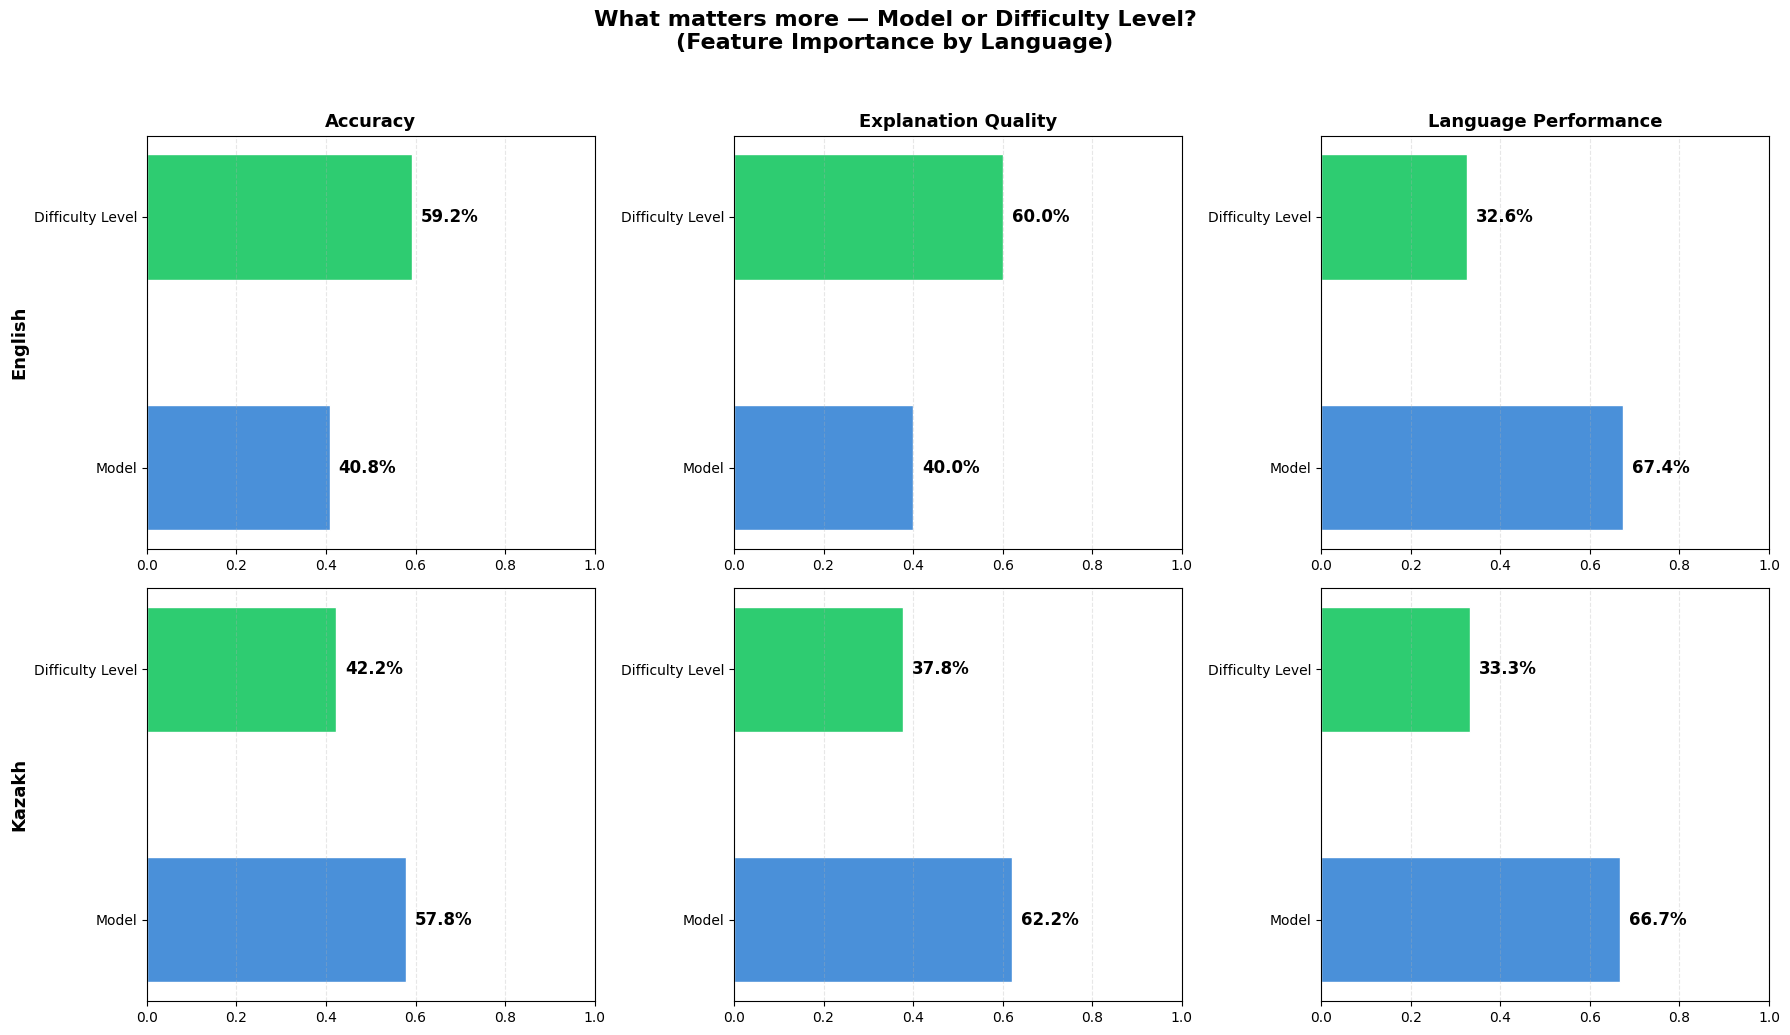

In [ ]:
le_model = LabelEncoder()
le_level = LabelEncoder()
df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Level_enc'] = le_level.fit_transform(df['Level'])

features = ['Model_enc', 'Level_enc']
feature_names = ['Model', 'Difficulty Level']
metrics = ['Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5']
metric_names = ['Accuracy', 'Explanation Quality', 'Language Performance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, lang in enumerate(['English', 'Kazakh']):
    subset = df[df['Language'] == lang]
    for col, (metric, mname) in enumerate(zip(metrics, metric_names)):
        X = subset[features].values
        y = subset[metric].astype(int).values
        rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=3)
        rf.fit(X, y)
        importances = rf.feature_importances_
        print(f"{lang} — {mname}: Model {importances[0]:.1%} / Level {importances[1]:.1%}")
        ax = axes[row][col]
        bars = ax.barh(feature_names, importances, color=['#4A90D9', '#2ECC71'], edgecolor='white', height=0.5)
        for bar, val in zip(bars, importances):
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{val:.1%}', va='center', fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        if row == 0:
            ax.set_title(mname, fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(lang, fontsize=13, fontweight='bold')

fig.suptitle('What matters more — Model or Difficulty Level?\n(Feature Importance by Language)',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/feature_importance_by_language.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Table: A+B vs C
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

print("=" * 90)
print("Mean Accuracy — Level A+B vs Level C")
print("=" * 90)

for lang in ['English', 'Kazakh', 'Both']:
    subset = df if lang == 'Both' else df[df['Language'] == lang]
    label = 'Overall (both languages)' if lang == 'Both' else lang
    print(f"\n--- {label} ---")
    rows = []
    for m in models_order:
        ab = subset[(subset['Model'] == m) & (subset['Level'].isin(['A', 'B']))]
        c = subset[(subset['Model'] == m) & (subset['Level'] == 'C')]
        ab_m = ab['Accuracy_0_2'].mean()
        c_m = c['Accuracy_0_2'].mean()
        drop = ab_m - c_m
        drop_pct = (drop / ab_m * 100) if ab_m > 0 else 0
        rows.append({'Model': m, 'A+B (M)': f"{ab_m:.2f}", 'n': len(ab),
                     'C (M)': f"{c_m:.2f}", 'n ': len(c),
                     'Drop': f"{drop:.2f}", 'Drop%': f"{drop_pct:.1f}%"})
    print(pd.DataFrame(rows).set_index('Model'))

# Table: A vs B vs C
print(f"\n\n{'='*90}")
print("Mean Accuracy by Level (A vs B vs C)")
print("=" * 90)

for lang in ['English', 'Kazakh', 'Both']:
    subset = df if lang == 'Both' else df[df['Language'] == lang]
    label = 'Overall (both languages)' if lang == 'Both' else lang
    print(f"\n--- {label} ---")
    rows = []
    for m in models_order:
        a = subset[(subset['Model'] == m) & (subset['Level'] == 'A')]['Accuracy_0_2']
        b = subset[(subset['Model'] == m) & (subset['Level'] == 'B')]['Accuracy_0_2']
        c = subset[(subset['Model'] == m) & (subset['Level'] == 'C')]['Accuracy_0_2']
        drop = a.mean() - c.mean()
        drop_pct = (drop / a.mean() * 100) if a.mean() > 0 else 0
        rows.append({'Model': m, 'A (M)': f"{a.mean():.2f}", 'n': len(a),
                     'B (M)': f"{b.mean():.2f}", 'n ': len(b),
                     'C (M)': f"{c.mean():.2f}", 'n  ': len(c),
                     'A→C Drop': f"{drop:.2f}", 'Drop%': f"{drop_pct:.1f}%"})
    print(pd.DataFrame(rows).set_index('Model'))

Mean Accuracy — Level A+B vs Level C

--- English ---
              A+B (M)   n C (M)  n   Drop  Drop%
Model                                           
Claude Sonnet    1.95  42  1.22  18  0.73  37.4%
GPT-4o           1.67  42  1.00  18  0.67  40.0%
Qwen2.5-7B       1.43  42  0.28  18  1.15  80.6%
KazLLM-8B        0.70  23  0.30  10  0.40  56.9%

--- Kazakh ---
              A+B (M)   n C (M)  n   Drop  Drop%
Model                                           
Claude Sonnet    1.79  42  0.94  18  0.84  47.1%
GPT-4o           1.64  42  1.00  18  0.64  39.1%
Qwen2.5-7B       0.98  42  0.17  18  0.81  82.9%
KazLLM-8B        0.26  23  0.10  10  0.16  61.7%

--- Overall (both languages) ---
              A+B (M)   n C (M)  n   Drop  Drop%
Model                                           
Claude Sonnet    1.87  84  1.08  36  0.79  42.0%
GPT-4o           1.65  84  1.00  36  0.65  39.6%
Qwen2.5-7B       1.20  84  0.22  36  0.98  81.5%
KazLLM-8B        0.48  46  0.20  20  0.28  58.2%


Mean Accurac

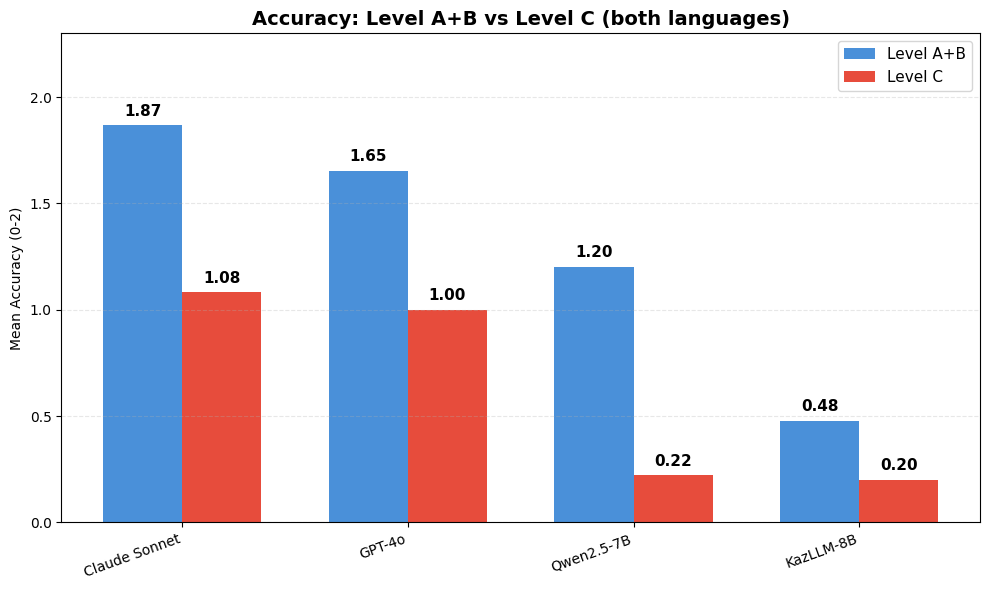

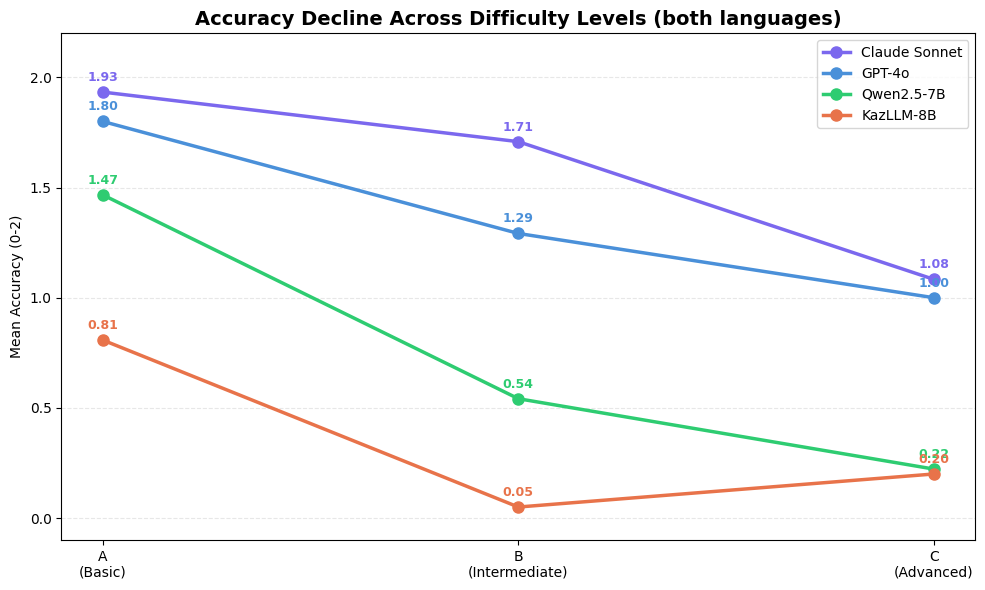

In [ ]:
# Graph 1: A+B vs C
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models_order))
width = 0.35

ab_means = [df[df['Level'].isin(['A', 'B']) & (df['Model'] == m)]['Accuracy_0_2'].mean() for m in models_order]
c_means = [df[(df['Level'] == 'C') & (df['Model'] == m)]['Accuracy_0_2'].mean() for m in models_order]

bars1 = ax.bar(x - width/2, ab_means, width, label='Level A+B', color='#4A90D9')
bars2 = ax.bar(x + width/2, c_means, width, label='Level C', color='#E74C3C')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.03, f'{h:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.03, f'{h:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Accuracy: Level A+B vs Level C (both languages)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=20, ha='right')
ax.set_ylabel('Mean Accuracy (0-2)')
ax.set_ylim(0, 2.3)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/accuracy_ab_vs_c.png', dpi=300, bbox_inches='tight')
plt.show()

# Graph 2: decline
fig, ax = plt.subplots(figsize=(10, 6))
colors_model = {'Claude Sonnet': '#7B68EE', 'GPT-4o': '#4A90D9', 'Qwen2.5-7B': '#2ECC71', 'KazLLM-8B': '#E8734A'}

for m in models_order:
    means = [df[(df['Model'] == m) & (df['Level'] == l)]['Accuracy_0_2'].mean() for l in ['A', 'B', 'C']]
    ax.plot(['A\n(Basic)', 'B\n(Intermediate)', 'C\n(Advanced)'], means, 'o-',
            linewidth=2.5, markersize=8, label=m, color=colors_model[m])
    for j, val in enumerate(means):
        ax.text(j, val + 0.05, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold', color=colors_model[m])

ax.set_title('Accuracy Decline Across Difficulty Levels (both languages)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Accuracy (0-2)')
ax.set_ylim(-0.1, 2.2)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/accuracy_decline_by_level.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
# Error type analysis
error_categories = [
    'Wrong method/wrong answer',
    'Correct method, calculation error',
    'Incomplete solution',
    'Grammar errors in Kazakh',
    'Unnatural Kazakh',
    'LaTeX formatting',
    'Wrong language (EN instead of KZ)',
]
short_labels = ['Wrong method', 'Calc error', 'Incomplete', 'Grammar KZ', 'Unnatural KZ', 'LaTeX', 'Wrong lang']
colors_err = ['#E74C3C', '#F39C12', '#3498DB', '#9B59B6', '#1ABC9C', '#E67E22', '#95A5A6']
models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']

In [11]:
try:
    df1 = pd.read_csv('/content/drive/MyDrive/Diploma project 2026/error types.csv', sep=',')
    print("Dataset loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'error types.csv' not found")

Dataset loaded successfully.



In [12]:
print(df1.columns.tolist())

['Problem_ID', 'Level', 'Language', 'Model', 'Accuracy_0_2', 'Explanation_Quality_1_5', 'Language_Performance_1_5', 'Error types']


In [13]:
# Clean error types data
df1 = df1.loc[:, ~df1.columns.str.contains('^Unnamed')]
df1 = df1.dropna(how='all')
df1 = df1.dropna(subset=['Model'])

models_order = ['Claude Sonnet', 'GPT-4o', 'Qwen2.5-7B', 'KazLLM-8B']
short_labels = ['Wrong method', 'Calc error', 'Incomplete', 'Grammar KZ', 'Unnatural KZ', 'LaTeX', 'Wrong lang']
colors_err = ['#E74C3C', '#F39C12', '#3498DB', '#9B59B6', '#1ABC9C', '#E67E22', '#95A5A6']

error_categories = [
    'Wrong method/wrong answer',
    'Correct method, calculation error',
    'Incomplete solution',
    'Grammar errors in Kazakh',
    'Unnatural Kazakh',
    'LaTeX formatting',
    'Wrong language (EN instead of KZ)',
]

def categorize(e):
    el = e.lower().strip()
    if 'wrong method' in el or 'wrong answer' in el: return 'Wrong method/wrong answer'
    if 'correct method' in el or 'calculation error' in el: return 'Correct method, calculation error'
    if 'incomplete' in el: return 'Incomplete solution'
    if 'grammar' in el: return 'Grammar errors in Kazakh'
    if 'unnatural' in el: return 'Unnatural Kazakh'
    if 'latex' in el: return 'LaTeX formatting'
    if 'wrong language' in el: return 'Wrong language (EN instead of KZ)'
    return None

def clean_errors(error_str):
    if pd.isna(error_str) or not str(error_str).strip():
        return []
    s = str(error_str).replace('\n', ', ')
    parts = [e.strip() for e in s.split(',') if e.strip()]
    cleaned = []
    i = 0
    while i < len(parts):
        if i+1 < len(parts) and parts[i].lower() == 'correct method' and parts[i+1].lower() == 'calculation error':
            cleaned.append('Correct method, calculation error')
            i += 2
        else:
            cleaned.append(parts[i])
            i += 1
    return [categorize(e) for e in cleaned if categorize(e)]

# Build error counts
from collections import Counter
data_err = {m: {lang: Counter() for lang in ['English', 'Kazakh']} for m in models_order}

for _, row in df1.iterrows():
    model = str(row['Model']).strip()
    if model not in models_order:
        continue
    lang = str(row['Language']).strip()
    for e in clean_errors(row['Error types']):
        data_err[model][lang][e] += 1

print("Error data loaded and cleaned.")

Error data loaded and cleaned.


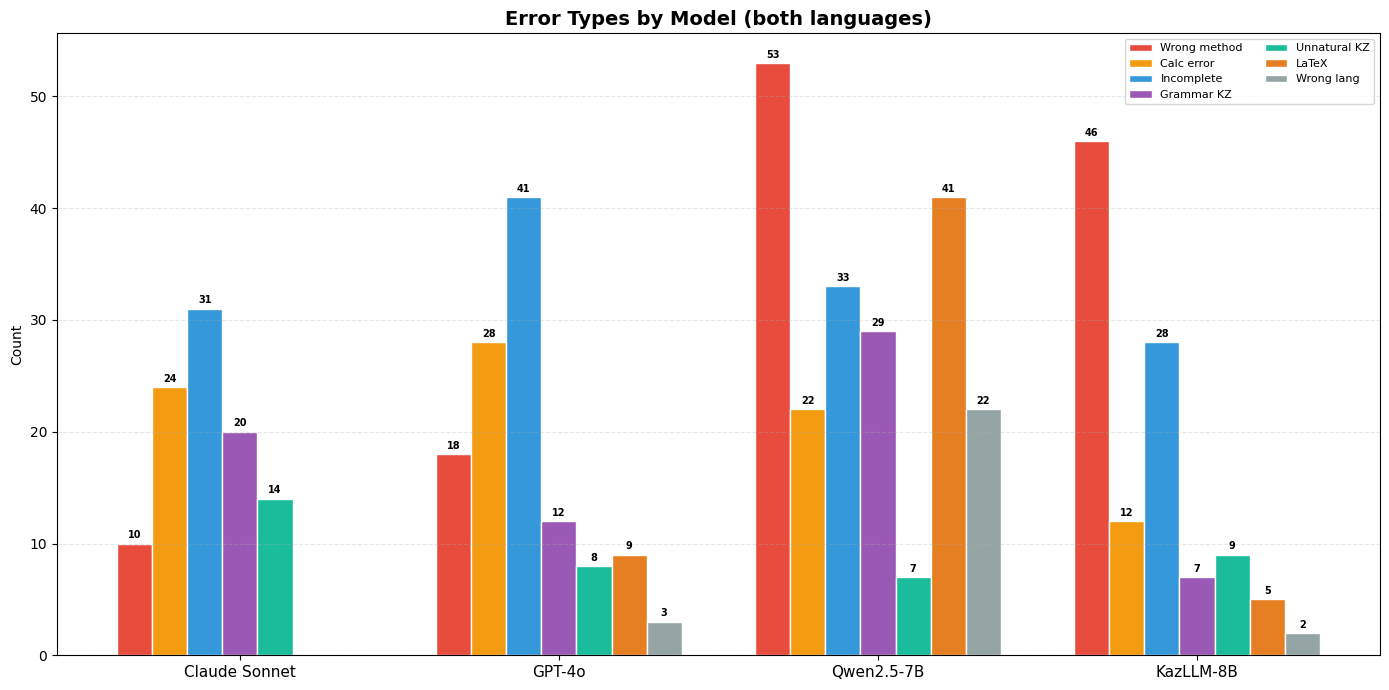

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(models_order))
width = 0.11

for idx, (cat, color, sl) in enumerate(zip(error_categories, colors_err, short_labels)):
    vals = [data_err[m]['English'].get(cat, 0) + data_err[m]['Kazakh'].get(cat, 0) for m in models_order]
    bars = ax.bar(x + idx * width, vals, width, label=sl, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                   str(val), ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_title('Error Types by Model (both languages)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 3)
ax.set_xticklabels(models_order, fontsize=11)
ax.set_ylabel('Count')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/error_types_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

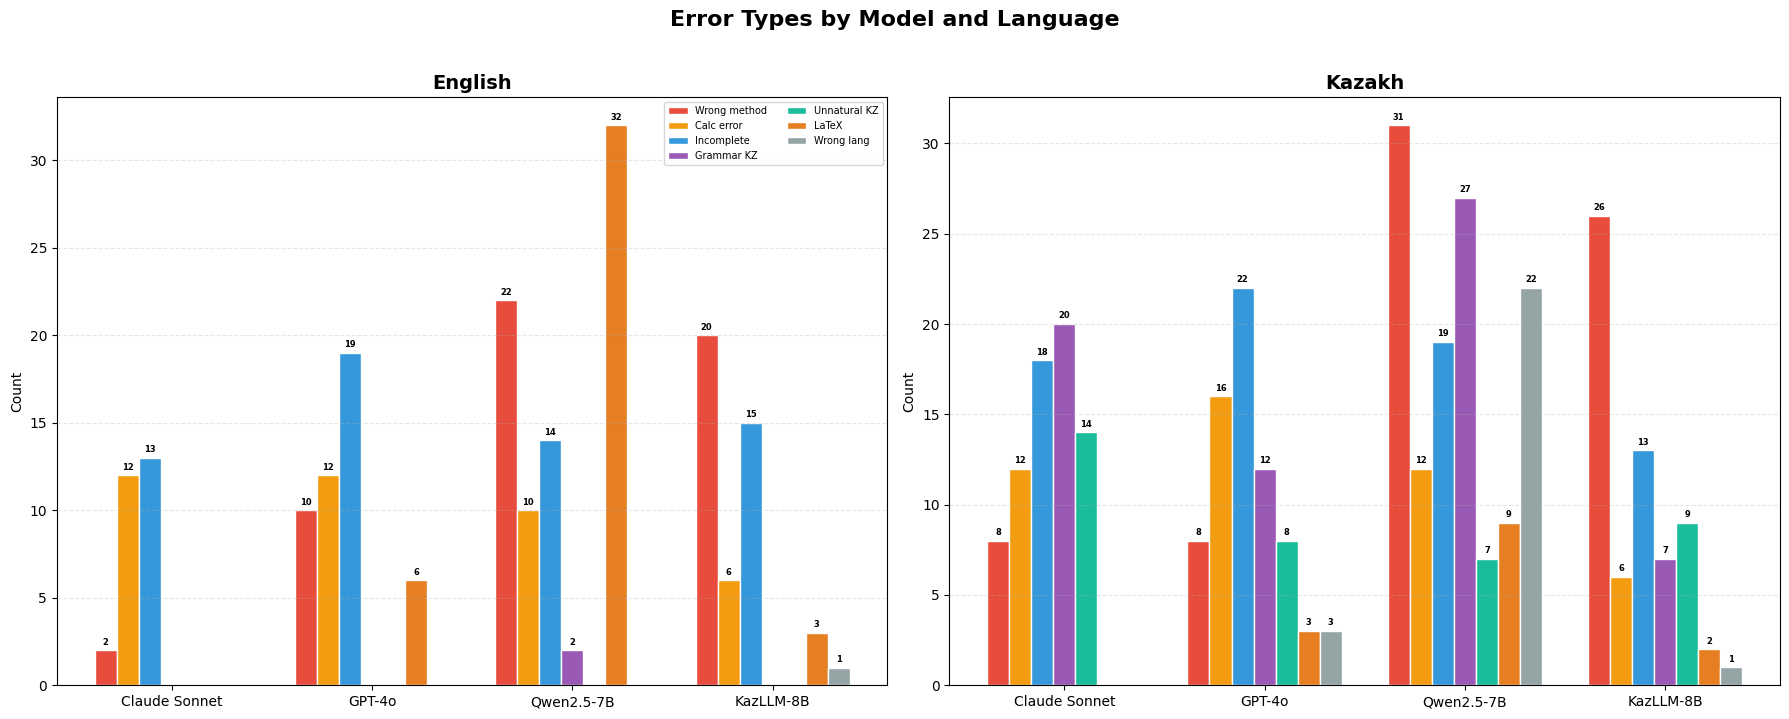

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for lidx, lang in enumerate(['English', 'Kazakh']):
    ax = axes[lidx]
    x = np.arange(len(models_order))
    for cidx, (cat, color, sl) in enumerate(zip(error_categories, colors_err, short_labels)):
        vals = [data_err[m][lang].get(cat, 0) for m in models_order]
        bars = ax.bar(x + cidx * 0.11, vals, 0.11, label=sl, color=color, edgecolor='white')
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                       str(val), ha='center', va='bottom', fontsize=6, fontweight='bold')
    ax.set_title(f'{lang}', fontsize=14, fontweight='bold')
    ax.set_xticks(x + 0.11 * 3)
    ax.set_xticklabels(models_order, fontsize=10)
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    if lidx == 0:
        ax.legend(fontsize=7, loc='upper right', ncol=2)

fig.suptitle('Error Types by Model and Language', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/error_types_by_model_language.png', dpi=300, bbox_inches='tight')
plt.show()

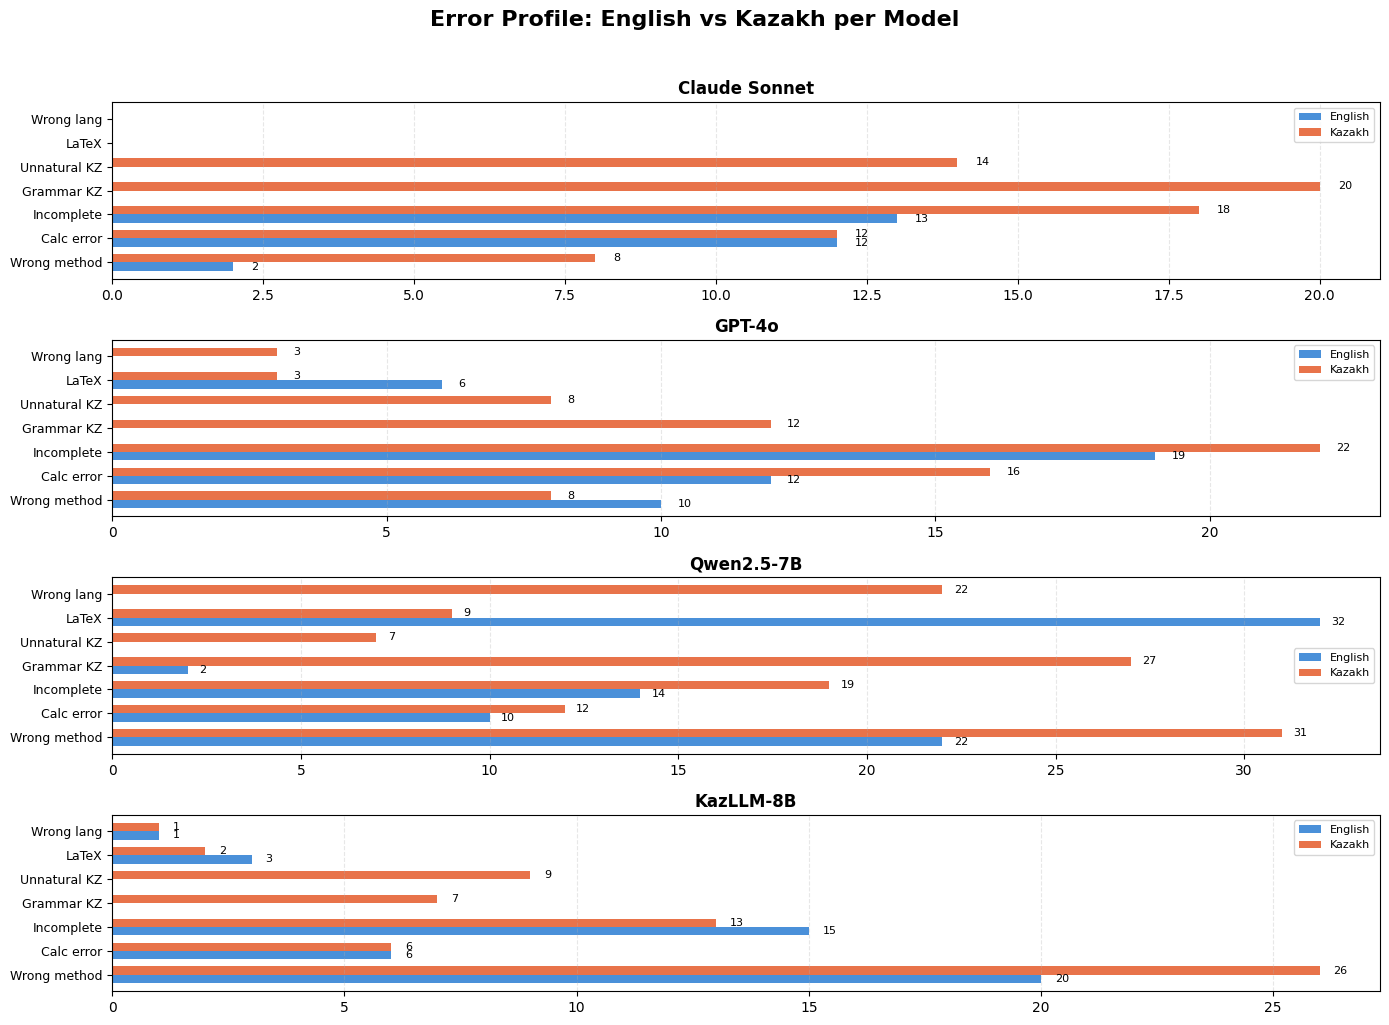

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

for idx, model in enumerate(models_order):
    ax = axes[idx]
    en_vals = [data_err[model]['English'].get(cat, 0) for cat in error_categories]
    kz_vals = [data_err[model]['Kazakh'].get(cat, 0) for cat in error_categories]
    y = np.arange(len(error_categories))
    height = 0.35
    bars1 = ax.barh(y - height/2, en_vals, height, label='English', color='#4A90D9')
    bars2 = ax.barh(y + height/2, kz_vals, height, label='Kazakh', color='#E8734A')
    for bar, val in zip(bars1, en_vals):
        if val > 0:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
    for bar, val in zip(bars2, kz_vals):
        if val > 0:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

fig.suptitle('Error Profile: English vs Kazakh per Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/error_profile_per_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Error types by model, language, difficulty Level
for level in ['A', 'B', 'C']:
    lname = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}
    print(f"\n{'='*90}")
    print(f"  {lname[level]}")
    print(f"{'='*90}")

    # Build counts for this level
    data_level = {m: {lang: Counter() for lang in ['English', 'Kazakh']} for m in models_order}
    for _, row in df1.iterrows():
        model = str(row['Model']).strip()
        if model not in models_order: continue
        if str(row['Level']).strip() != level: continue
        lang = str(row['Language']).strip()
        for e in clean_errors(row['Error types']):
            data_level[model][lang][e] += 1

    for lang in ['English', 'Kazakh']:
        print(f"\n  {lang}:")
        header = f"  {'Model':<15}"
        for sl in short_labels:
            header += f" {sl:>12}"
        header += f" {'Total':>8}"
        print(header)
        for m in models_order:
            row_str = f"  {m:<15}"
            total = 0
            for cat in error_categories:
                val = data_level[m][lang].get(cat, 0)
                row_str += f" {val:>12}"
                total += val
            row_str += f" {total:>8}"
            print(row_str)


  Level A (Basic)

  English:
  Model           Wrong method   Calc error   Incomplete   Grammar KZ Unnatural KZ        LaTeX   Wrong lang    Total
  Claude Sonnet              0            1            0            0            0            0            0        1
  GPT-4o                     2            2            0            0            0            6            0       10
  Qwen2.5-7B                 2            4            1            0            0           22            0       29
  KazLLM-8B                  3            5            2            0            0            2            0       12

  Kazakh:
  Model           Wrong method   Calc error   Incomplete   Grammar KZ Unnatural KZ        LaTeX   Wrong lang    Total
  Claude Sonnet              0            3            4           14           11            0            0       32
  GPT-4o                     0            5            3            8            6            2            1       25
  Qwen2.5-7B  

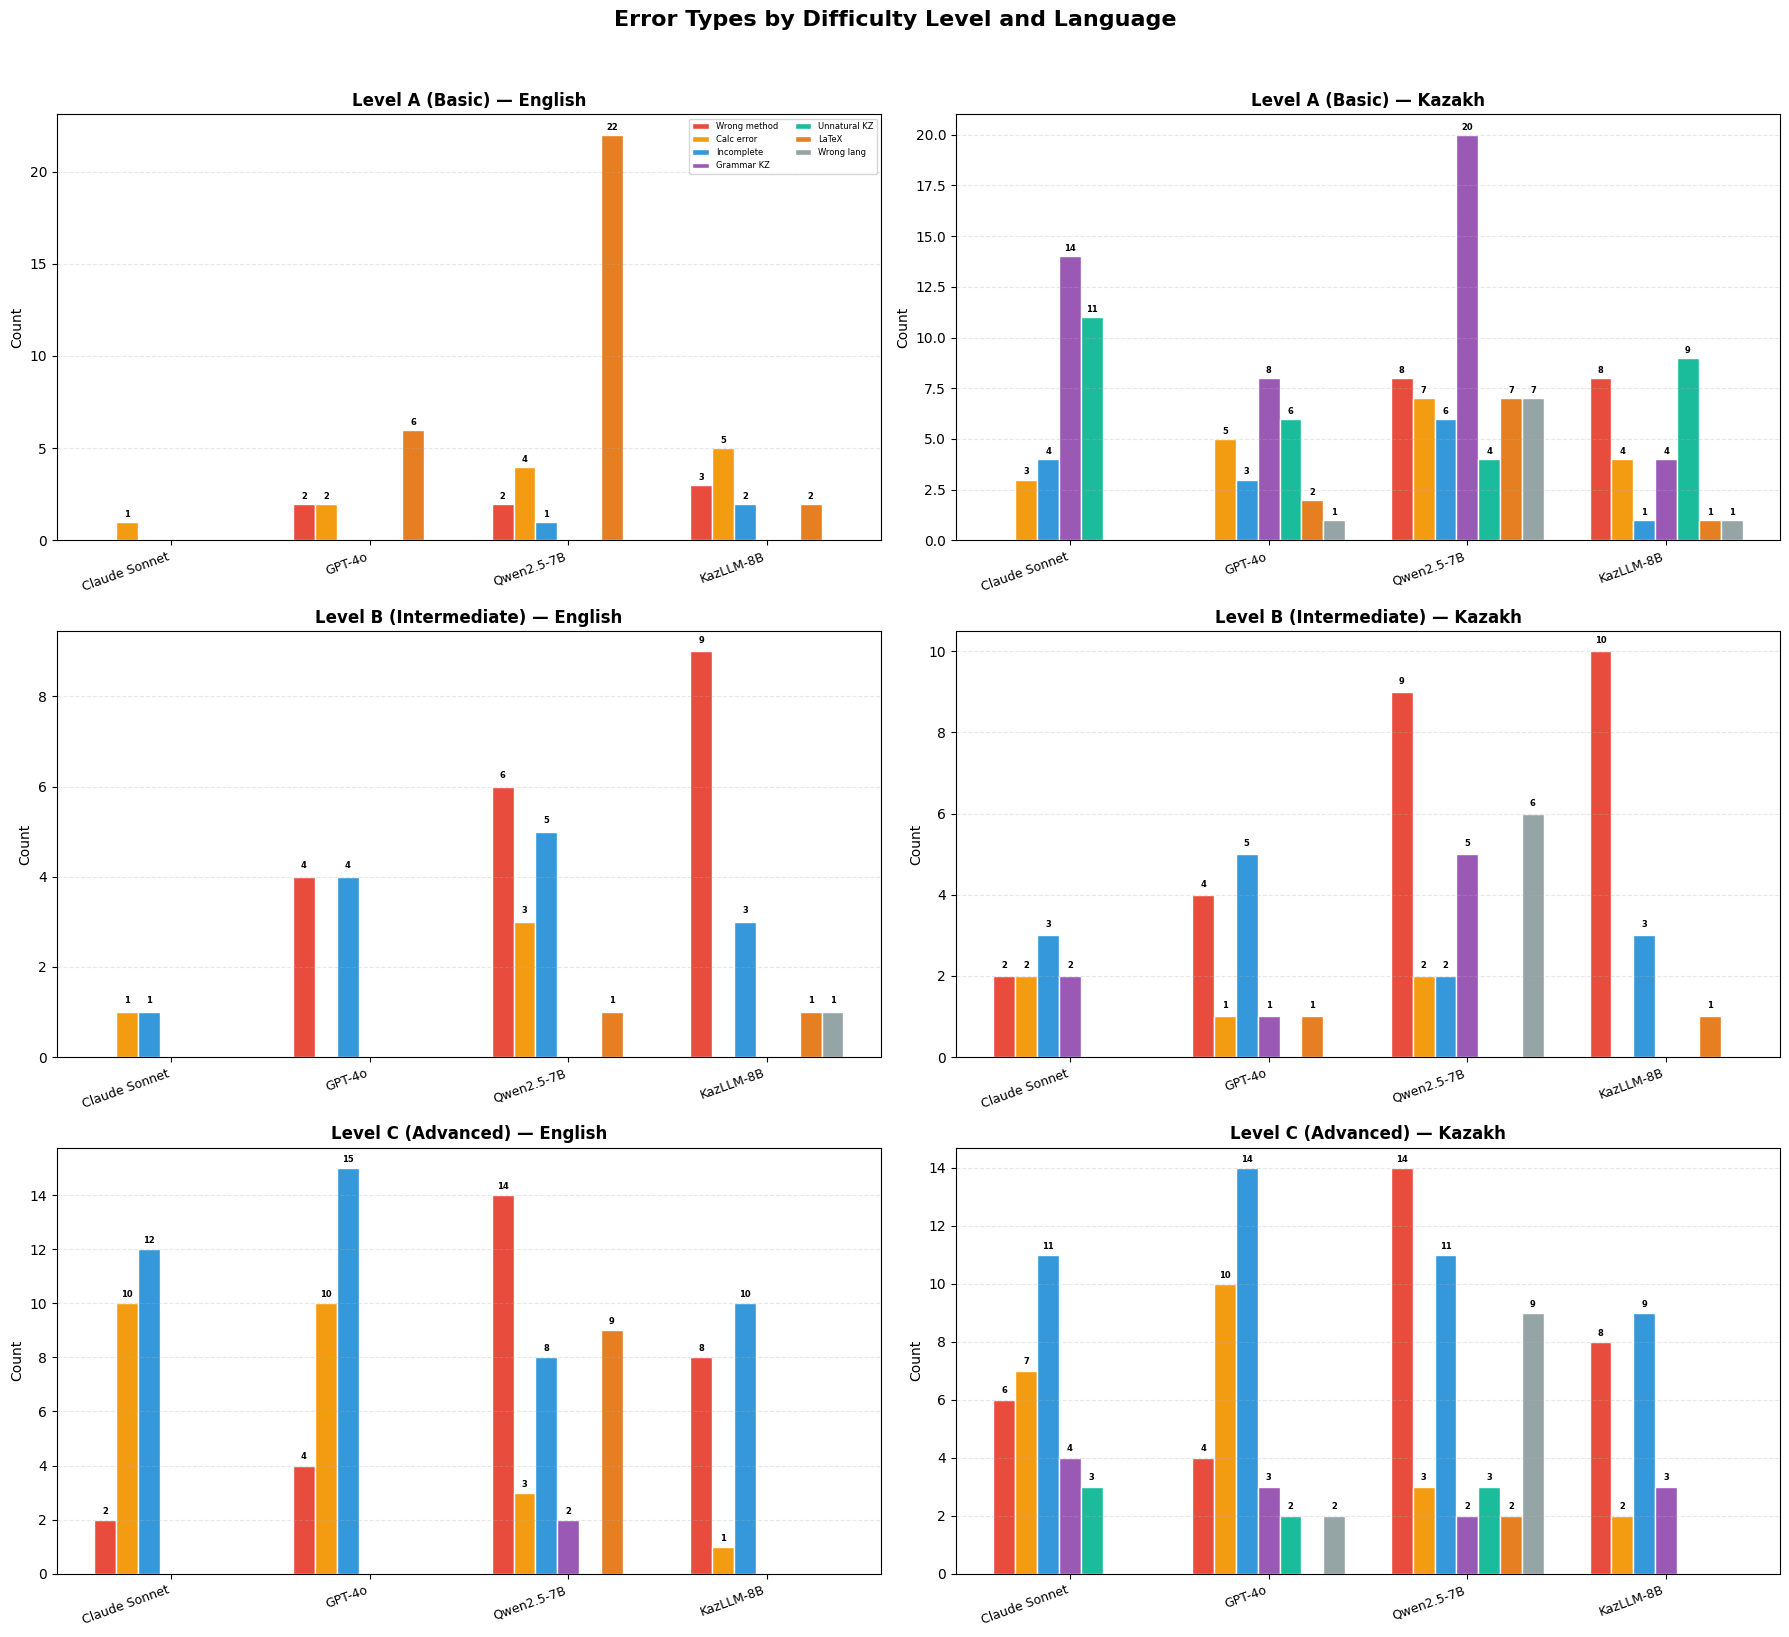

In [18]:
# Error types by difficulty level — stacked horizontal per model
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
level_labels = {'A': 'Level A (Basic)', 'B': 'Level B (Intermediate)', 'C': 'Level C (Advanced)'}

for row_idx, level in enumerate(['A', 'B', 'C']):
    # Build counts for this level
    data_level = {m: {lang: Counter() for lang in ['English', 'Kazakh']} for m in models_order}
    for _, row in df1.iterrows():
        model = str(row['Model']).strip()
        if model not in models_order: continue
        if str(row['Level']).strip() != level: continue
        lang = str(row['Language']).strip()
        for e in clean_errors(row['Error types']):
            data_level[model][lang][e] += 1

    for col_idx, lang in enumerate(['English', 'Kazakh']):
        ax = axes[row_idx][col_idx]
        x = np.arange(len(models_order))
        for cidx, (cat, color, sl) in enumerate(zip(error_categories, colors_err, short_labels)):
            vals = [data_level[m][lang].get(cat, 0) for m in models_order]
            bars = ax.bar(x + cidx * 0.11, vals, 0.11, label=sl, color=color, edgecolor='white')
            for bar, val in zip(bars, vals):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.15,
                           str(val), ha='center', va='bottom', fontsize=6, fontweight='bold')
        ax.set_title(f'{level_labels[level]} — {lang}', fontsize=12, fontweight='bold')
        ax.set_xticks(x + 0.11 * 3)
        ax.set_xticklabels(models_order, fontsize=9, rotation=20, ha='right')
        ax.set_ylabel('Count')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, loc='upper right', ncol=2)

fig.suptitle('Error Types by Difficulty Level and Language', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Diploma project 2026/error_types_by_level.png', dpi=300, bbox_inches='tight')
plt.show()